 ***Spatial analysis of natural scenes notebook***
 
This notebook is created to generate plots for the spatial analysis paper from the `SCENES` dataset.

In [1]:
import os
import re
import math
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from cmcrameri import cm     #Scientific color maps
from matplotlib.pyplot import figure
import matplotlib.dates as mdates
from matplotlib import gridspec
import matplotlib.image as mpimg
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker
import seaborn as sns
import csv  
import scipy.stats as stats
from scipy.stats import gaussian_kde
from scipy.stats import linregress

from utils import scenes_functions

In [2]:
# Display data frames in scrolling format
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [3]:
# Set default font properties
rcParams['font.family'] = 'Arial'
# Disable LaTeX rendering for text
rcParams['text.usetex'] = False  # This prevents LaTeX formatting in the tick labels
rcParams['font.size'] = 10

In [4]:
# Color palettes

# Choose the sequential color palette from cmcrameri
cmap = cm.batlow
cmap_blues = plt.colormaps["Blues"] 

# Define the custom color palette
photoreceptor_colors = {
    'L cones': (0.8941, 0.1020, 0.1098),
    'M cones': (0.3020, 0.6863, 0.2902),
    'S cones': (0.2157, 0.4941, 0.7216),
    'Rods': (0.0157, 0.4118, 0.3333),
    'Melanopsin': (0.1255, 0.6549, 0.7686)   
}

# Preprocessing

## directory paths

In [5]:
# External dataset paths
#=================================================================
# Update `dataset_dir` below to point to that local dataset location.
#=================================================================

dataset_dir = snakemake.params.data_dir

wp_derivatives_dir = os.path.join(dataset_dir, "derivatives", "wp_derivatives")
metadata_dir = os.path.join(dataset_dir, "metadata")

In [6]:
# Working directory paths

code_dir = os.getcwd()
repository = snakemake.params.repo_root

data_dir = os.path.join(repository, "data")
results_dir = os.path.join(repository, "results")
figures_dir = os.path.join(results_dir, "figures")
tables_dir = os.path.join(results_dir, "tables")

## Merged metadata, Jeti and WestBoro metrics

In [7]:
# Read the dataframe generated in "WP_derivatives" notebook from the csv file (merged_wp_jeti_metadata_df.csv)

merged_wp_jeti_metadata_df = pd.read_csv(
    os.path.join(tables_dir, "merged_wp_jeti_metadata_df.csv"),
    header=0,
    index_col=0)

merged_wp_jeti_metadata_df["view"] = merged_wp_jeti_metadata_df["view"].apply(lambda x: x if x.endswith(" view") else f"{x} view")

merged_wp_jeti_metadata_df.shape[0]

671

In [8]:
locations = merged_wp_jeti_metadata_df["location"].unique()
locations

<StringArray>
[        'Ottawa (Canada)',      'Tübingen (Germany)',
           'Lyon (France)', 'Prague (Czech Republic)',
        'Munich (Germany)']
Length: 5, dtype: str

In [9]:
views = merged_wp_jeti_metadata_df["view"].unique()
views

<StringArray>
['Outdoor view', 'Indoor w/ window view', 'Indoor w/o window view']
Length: 3, dtype: str

In [10]:
# Get unique values in 'view' and their counts
view_counts = merged_wp_jeti_metadata_df['view'].value_counts()

# Print the unique values and their counts
print(f'Views and counts:\n{view_counts}')

Views and counts:
view
Outdoor view              362
Indoor w/ window view     194
Indoor w/o window view    115
Name: count, dtype: int64


In [11]:
# Create a color mapping for 'view' using the cmap to ensure consistent colors

# Define the color palette
cmap_colors = [cmap(i / len(views)) for i in range(len(views))]

# Map the colors to the views in the specified order
view_color_mapping = dict(zip(['Indoor w/o window view', 'Indoor w/ window view', 'Outdoor view'], cmap_colors))


## Central statistics

In [12]:
# Jeti central stats

selected_columns_jeti = [
    "Illuminance [lx] (CIE1931 2°)", 
    "Correlated Color Temp. (CCT) [K]", 
    "Esc [W/sqm]", 
    "Emc [W/sqm]", 
    "Elc [W/sqm]", 
    "Erh [W/sqm]", 
    "Emel [W/sqm]", 
    "X v,mel,D65 (MEDI) [lx]"
]

# Calculate overall statistics (mean, min, max, std) for these selected columns
overall_stats_jeti = merged_wp_jeti_metadata_df[selected_columns_jeti].agg(
    ['mean','std', 'median', 'min', 'max']).transpose()

# Calculate IQR (Interquartile Range)
overall_stats_jeti['IQR'] = (
    merged_wp_jeti_metadata_df[selected_columns_jeti].quantile(0.75) -
    merged_wp_jeti_metadata_df[selected_columns_jeti].quantile(0.25)
)

overall_stats_jeti.columns = [
    'overall_mean', 'overall_std', 'overall_median', 'overall_min', 'overall_max', 'overall_IQR'
]

overall_stats_jeti.reset_index(inplace=True)


# Save the Overal stats as a csv
overall_stats_jeti.to_csv(os.path.join(tables_dir, 'jeti_statistics_overall.csv'), sep=',', index=False)


In [13]:
# Group by "view" and calculate statistics
view_stats_jeti = merged_wp_jeti_metadata_df.groupby("view")[selected_columns_jeti].agg(
    ['mean', 'std', 'median', 'min', 'max']
)

# Calculate IQR (Interquartile Range) for each group
iqr = merged_wp_jeti_metadata_df.groupby("view")[selected_columns_jeti].quantile(0.75) - \
      merged_wp_jeti_metadata_df.groupby("view")[selected_columns_jeti].quantile(0.25)

# Correctly add IQR as a new level in the MultiIndex DataFrame
for col in selected_columns_jeti:
    view_stats_jeti[(col, 'IQR')] = iqr[col]

# Sort columns for better readability
view_stats_jeti = view_stats_jeti.sort_index(axis=1)

# Save the Viwe stats as a csv
view_stats_jeti.to_csv(os.path.join(tables_dir, 'jeti_statistics_per_view.csv'), sep=',')

In [14]:
overall_stats_jeti

,index,overall_mean,overall_std,overall_median,overall_min,overall_max,overall_IQR
0,Illuminance [lx] (CIE1931 2°),8005.208495,17375.292904,1501.8,0.2,110872.8,6137.15
1,Correlated Color Temp. (CCT) [K],5753.394933,1727.997322,5699.0,0.0,17246.0,1652.50
2,Esc [W/sqm],5.598510,11.468817,1.2,0.0,72.7,5.50
3,Emc [W/sqm],11.313562,24.330349,2.1,0.0,155.1,9.10
4,Elc [W/sqm],13.045604,28.326563,2.4,0.0,180.8,10.00
5,Erh [W/sqm],10.752757,22.827092,2.1,0.0,145.2,9.45
6,Emel [W/sqm],9.669001,20.403880,1.9,0.0,129.8,8.85
7,"X v,mel,D65 (MEDI) [lx]",7288.514456,15380.002467,1448.9,0.2,97807.5,6647.35


In [15]:
view_stats_jeti

Correlated Color Temp. (CCT) [K]                        \
                                                    IQR      max         mean   
view                                                                            
Indoor w/ window view                           1806.25  11520.0  5344.288660   
Indoor w/o window view                          1335.50   5996.0  4233.373913   
Outdoor view                                    1273.00  17246.0  6455.519337   

                                                    Elc [W/sqm]         \
                        median     min          std         IQR    max   
view                                                                     
Indoor w/ window view   4942.0  2919.0  1371.343836       1.575  103.4   
Indoor w/o window view  4034.0  3377.0   701.667606       0.600    3.2   
Outdoor view            6007.5     0.0  1749.469967      16.250  180.8   

                                                         Emc [W/sqm]         \
                             mean median  min        std         IQR    max   
view                                                                          
Indoor w/ window view    4.392784    1.2  0.0  15.089853        1.40   89.4   
Indoor w/o window view   0.629565    0.4  0.0   0.594562        0.50    2.6   
Outdoor view            21.627072    9.4  0.0  34.701159       14.05  155.1   

                                                         Emel [W/sqm]         \
                             mean median  min        std          IQR    max   
view                                                                           
Indoor w/ window view    3.825258   1.00  0.0  13.050156        1.200   73.2   
Indoor w/o window view   0.520870   0.30  0.0   0.511190        0.300    1.9   
Outdoor view            18.755249   8.45  0.0  29.744858       12.325  129.8   

                                                         Erh [W/sqm]         \
                             mean median  min        std         IQR    max   
view                                                                          
Indoor w/ window view    3.162887    0.8  0.0  10.678401       1.200   82.7   
Indoor w/o window view   0.373043    0.2  0.0   0.418921       0.400    2.2   
Outdoor view            16.108840    7.7  0.0  24.895543      13.475  145.2   

                                                         Esc [W/sqm]        \
                             mean median  min        std         IQR   max   
view                                                                         
Indoor w/ window view    3.556186   0.90  0.0  12.068543         0.7  38.7   
Indoor w/o window view   0.432174   0.20  0.0   0.472498         0.1   1.0   
Outdoor view            17.888122   8.35  0.0  27.862839         7.4  72.7   

                                                         \
                            mean median  min        std   
view                                                      
Indoor w/ window view   1.730412    0.4  0.0   5.640210   
Indoor w/o window view  0.188696    0.1  0.0   0.224689   
Outdoor view            9.390055    4.6  0.0  13.975626   

                       Illuminance [lx] (CIE1931 2°)                          \
                                                 IQR       max          mean   
view                                                                           
Indoor w/ window view                        964.000   63721.1   2707.866495   
Indoor w/o window view                       367.000    1959.1    387.018261   
Outdoor view                                9988.775  110872.8  13264.258840   

                                                   X v,mel,D65 (MEDI) [lx]  \
                        median   min           std                     IQR   
view                                                                         
Indoor w/ window view    723.9  13.9   9298.206051                 862.450   
Indoor w/o window view   259.5  13.8    366

In [16]:
# WP central stats

# Select columns that end with 'Mean' or start with 'rms'
selected_columns = [
    col for col in merged_wp_jeti_metadata_df.columns
    if col.startswith('average_radiances') or col.startswith('rms')
]

# Calculate overall statistics (mean, min, max, std) for these selected columns
overall_stats = merged_wp_jeti_metadata_df[selected_columns].agg(
    ['mean','std', 'median', 'min', 'max']).transpose()

# Calculate IQR (Interquartile Range)
overall_stats['IQR'] = (
    merged_wp_jeti_metadata_df[selected_columns].quantile(0.75) -
    merged_wp_jeti_metadata_df[selected_columns].quantile(0.25)
)

overall_stats.columns = [
    'overall_mean', 'overall_std', 'overall_median', 'overall_min', 'overall_max', 'overall_IQR'
]

overall_stats.reset_index(inplace=True)

# Calculate statistics (mean, max, std) by 'view' category for these selected columns
view_stats = merged_wp_jeti_metadata_df.groupby('view')[selected_columns].agg(
    ['mean','std', 'median', 'min', 'max'])

# Calculate IQR (Interquartile Range) by 'view'
IQR = (
    merged_wp_jeti_metadata_df.groupby('view')[selected_columns].quantile(0.75) -
    merged_wp_jeti_metadata_df.groupby('view')[selected_columns].quantile(0.25)
)
IQR.columns = pd.MultiIndex.from_product([IQR.columns, ['IQR']])

view_stats = pd.concat([view_stats, IQR], axis=1)
view_stats.reset_index(inplace=True)
# Reset index and flatten the multi-level columns for view stats
view_stats.columns = ['_'.join(col).strip() for col in view_stats.columns]



# Transpose the DataFrame to have 'view' as columns and metrics as rows
view_stats.rename(columns={'view_': 'view'}, inplace=True)

# Rearranging the columns to have the desired order
new_columns = []
for col in selected_columns:
    new_columns.extend([f"{col}_mean", f"{col}_std", f"{col}_median", f"{col}_min", f"{col}_max", f"{col}_IQR"])

# Ensure to include the 'view' column at the front
new_columns = ['view'] + new_columns

# Reindex view_stats DataFrame to have columns in the new order
view_stats = view_stats[new_columns]

view_stats = view_stats.round(4)

# Save the Overal stats as a csv

overall_stats.to_csv(os.path.join(tables_dir, 'wp_statistics_overall.csv'), sep=',')

In [17]:
overall_stats

,index,overall_mean,overall_std,overall_median,overall_min,overall_max,overall_IQR
0,average_radiances_L cones,1.892643,2.367183,0.7658,0.0004,10.9462,2.56910
1,average_radiances_M cones,1.923061,2.775011,0.6816,0.0006,15.7464,2.34520
2,average_radiances_S cones,1.049948,1.628125,0.3140,0.0001,10.2478,1.13215
3,average_radiances_Rods,1.553982,1.953138,0.6292,0.0002,8.4730,2.04200
4,average_radiances_Melanopsin,1.604801,2.261870,0.5614,0.0002,10.9764,1.95580
5,rms_contrast_L cones,0.139534,0.078832,0.1304,0.0010,0.3808,0.11480
6,rms_contrast_M cones,0.125720,0.078327,0.1113,0.0008,0.3724,0.11340
7,rms_contrast_S cones,0.136270,0.083977,0.1269,0.0008,0.3880,0.11485
8,rms_contrast_Rods,0.150573,0.084413,0.1368,0.0012,0.3891,0.12395
9,rms_contrast_Melanopsin,0.142995,0.084716,0.1287,0.0012,0.3890,0.12270


In [18]:
view_stats

,view,average_radiances_L cones_mean,average_radiances_L cones_std,average_radiances_L cones_median,average_radiances_L cones_min,average_radiances_L cones_max,average_radiances_L cones_IQR,average_radiances_M cones_mean,average_radiances_M cones_std,average_radiances_M cones_median,average_radiances_M cones_min,average_radiances_M cones_max,average_radiances_M cones_IQR,average_radiances_S cones_mean,average_radiances_S cones_std,average_radiances_S cones_median,average_radiances_S cones_min,average_radiances_S cones_max,average_radiances_S cones_IQR,average_radiances_Rods_mean,average_radiances_Rods_std,average_radiances_Rods_median,average_radiances_Rods_min,average_radiances_Rods_max,average_radiances_Rods_IQR,average_radiances_Melanopsin_mean,average_radiances_Melanopsin_std,average_radiances_Melanopsin_median,average_radiances_Melanopsin_min,average_radiances_Melanopsin_max,average_radiances_Melanopsin_IQR,rms_contrast_L cones_mean,rms_contrast_L cones_std,rms_contrast_L cones_median,rms_contrast_L cones_min,rms_contrast_L cones_max,rms_contrast_L cones_IQR,rms_contrast_M cones_mean,rms_contrast_M cones_std,rms_contrast_M cones_median,rms_contrast_M cones_min,rms_contrast_M cones_max,rms_contrast_M cones_IQR,rms_contrast_S cones_mean,rms_contrast_S cones_std,rms_contrast_S cones_median,rms_contrast_S cones_min,rms_contrast_S cones_max,rms_contrast_S cones_IQR,rms_contrast_Rods_mean,rms_contrast_Rods_std,rms_contrast_Rods_median,rms_contrast_Rods_min,rms_contrast_Rods_max,rms_contrast_Rods_IQR,rms_contrast_Melanopsin_mean,rms_contrast_Melanopsin_std,rms_contrast_Melanopsin_median,rms_contrast_Melanopsin_min,rms_contrast_Melanopsin_max,rms_contrast_Melanopsin_IQR
0,Indoor w/ window view,1.0201,1.5954,0.3768,0.0083,6.8467,0.6834,0.9750,1.6437,0.3334,0.0068,8.2032,0.6957,0.4998,0.8728,0.1526,0.0021,4.3358,0.3385,0.8612,1.3388,0.3143,0.0048,5.5223,0.6050,0.8395,1.4113,0.2867,0.0036,6.4896,0.5650,0.1294,0.0753,0.1224,0.0048,0.3409,0.0891,0.1196,0.0724,0.1152,0.0025,0.3424,0.0777,0.1302,0.0800,0.1221,0.0016,0.3579,0.0760,0.1378,0.0824,0.1250,0.0037,0.3452,0.1057,0.1333,0.0784,0.1250,0.0025,0.3451,0.0834
1,Indoor w/o window view,0.1687,0.2287,0.1008,0.0074,1.7264,0.1654,0.1394,0.1670,0.0783,0.0070,0.8279,0.1211,0.0509,0.0657,0.0209,0.0025,0.2937,0.0546,0.1251,0.2116,0.0573,0.0061,1.8512,0.1128,0.1070,0.1890,0.0456,0.0050,1.6655,0.0845,0.0960,0.0611,0.0807,0.0168,0.2079,0.1100,0.0902,0.0591,0.0811,0.0152,0.2037,0.0926,0.0871,0.0534,0.0773,0.0178,0.2033,0.0867,0.0939,0.0600,0.0816,0.0169,0.2020,0.1145,0.0919,0.0586,0.0822,0.0175,0.2029,0.1058
2,Outdoor view,2.9079,2.5755,2.1204,0.0004,10.9462,3.7780,2.9978,3.1913,1.7768,0.0006,15.7464,3.7444,1.6622,1.9117,0.8262,0.0001,10.2478,2.2489,2.3792,2.1252,1.6200,0.0002,8.4730,3.2448,2.4908,2.5695,1.4308,0.0002,10.9764,3.2720,0.1588,0.0793,0.1488,0.0010,0.3808,0.1256,0.1403,0.0827,0.1312,0.0008,0.3724,0.1334,0.1551,0.0873,0.1482,0.0008,0.3880,0.1334,0.1754,0.0820,0.1747,0.0012,0.3891,0.1168,0.1644,0.0872,0.1474,0.0012,0.3890,0.1422


In [19]:
# Define selected columns based on column names starting with 'average' or 'rms'

selected_columns = [
    col for col in merged_wp_jeti_metadata_df.columns
    if col.startswith('average') or col.startswith('rms')
]

# Calculate basic statistics (mean, std, median, min, max) by 'view' category for these selected columns
view_stats_table = merged_wp_jeti_metadata_df.groupby('view')[selected_columns].agg(
    ['mean', 'std', 'median', 'min', 'max']
)

# Calculate IQR (Interquartile Range) by 'view'
IQR = (
    merged_wp_jeti_metadata_df.groupby('view')[selected_columns].quantile(0.75) -
    merged_wp_jeti_metadata_df.groupby('view')[selected_columns].quantile(0.25)
)
# Rename the columns in IQR to match the multi-index format
IQR.columns = pd.MultiIndex.from_product([IQR.columns, ['IQR']])

view_stats_table = pd.concat([view_stats_table, IQR], axis=1)

# Reset the column levels so that 'view' categories are top-level headers, and stats are subheaders
view_stats_table = view_stats_table.stack(level=0, future_stack=True).unstack(level=0)

# Now adjust columns to have MultiIndex with view categories at the top-level, stats as sub-level
view_stats_table.columns = pd.MultiIndex.from_product(
    [view_stats_table.columns.levels[1], ['mean', 'std', 'median', 'min', 'max', 'IQR']],
    names=['View', 'Statistic']
)

# Reset index so 'selected_columns' become the row index with "Metric" as the label
view_stats_table = view_stats_table.reset_index().rename(columns={'level_0': 'Metric'})

# Optional: rounding the data to 4 decimal places for clarity
view_stats_table = view_stats_table.round(4)

# Save the DataFrame to a CSV file
view_stats_table.to_csv(os.path.join(tables_dir, 'wp_statistics_per_view.csv'), sep=',', index=False)


In [20]:
view_stats_table

View                              index Indoor w/ window view                  \
Statistic                                                mean     std  median   
0             average_radiances_L cones                1.0201  0.1687  2.9079   
1             average_radiances_M cones                0.9750  0.1394  2.9978   
2             average_radiances_S cones                0.4998  0.0509  1.6622   
3                average_radiances_Rods                0.8612  0.1251  2.3792   
4          average_radiances_Melanopsin                0.8395  0.1070  2.4908   
5             average_luminance_L cones                0.6263  0.1036  1.7852   
6             average_luminance_M cones                0.6697  0.0958  2.0591   
7             average_luminance_S cones                0.3769  0.0384  1.2533   
8                average_luminance_Rods                0.5940  0.0863  1.6412   
9          average_luminance_Melanopsin                1.0271  0.1309  3.0476   
10                 rms_contrast_L cones                0.1294  0.0960  0.1588   
11                 rms_contrast_M cones                0.1196  0.0902  0.1403   
12                 rms_contrast_S cones                0.1302  0.0871  0.1551   
13                    rms_contrast_Rods                0.1378  0.0939  0.1754   
14              rms_contrast_Melanopsin                0.1333  0.0919  0.1644   

View                              Indoor w/o window view                  \
Statistic     min     max     IQR                   mean     std  median   
0          1.5954  0.2287  2.5755                 0.3768  0.1008  2.1204   
1          1.6437  0.1670  3.1913                 0.3334  0.0783  1.7768   
2          0.8728  0.0657  1.9117                 0.1526  0.0209  0.8262   
3          1.3388  0.2116  2.1252                 0.3143  0.0573  1.6200   
4          1.4113  0.1890  2.5695                 0.2867  0.0456  1.4308   
5          0.9794  0.1404  1.5811                 0.2313  0.0619  1.3017   
6          1.1290  0.1147  2.1921                 0.2290  0.0538  1.2205   
7          0.6581  0.0495  1.4415                 0.1150  0.0158  0.6229   
8          0.9235  0.1460  1.4659                 0.2168  0.0395  1.1175   
9          1.7268  0.2313  3.1440                 0.3508  0.0558  1.7507   
10         0.0753  0.0611  0.0793                 0.1224  0.0807  0.1488   
11         0.0724  0.0591  0.0827                 0.1152  0.0811  0.1312   
12         0.0800  0.0534  0.0873                 0.1221  0.0773  0.1482   
13         0.0824  0.0600  0.0820                 0.1250  0.0816  0.1747   
14         0.0784  0.0586  0.0872                 0.1250  0.0822  0.1474   

View                              Outdoor view                           \
Statistic     min     max     IQR         mean     std   median     min   
0          0.0083  0.0074  0.0004       6.8467  1.7264  10.9462  0.6834   
1          0.0068  0.0070  0.0006       8.2032  0.8279  15.7464  0.6957   
2          0.0021  0.0025  0.0001       4.3358  0.2937  10.2478  0.3385   
3          0.0048  0.0061  0.0002       5.5223  1.8512   8.4730  0.6050   
4          0.0036  0.0050  0.0002       6.4896  1.6655  10.9764  0.5650   
5          0.0051  0.0045  0.0002       4.2032  1.0599   6.7200  0.4195   
6          0.0047  0.0048  0.0004       5.6347  0.5687  10.8161  0.4778   
7          0.0016  0.0019  0.0001       3.2693  0.2215   7.7271  0.2552   
8          0.0033  0.0042  0.0001       3.8093  1.2770   5.8446  0.4173   
9          0.0044  0.0061  0.0002       7.9404  2.0378  13.4302  0.6913   
10         0.0048  0.0168  0.0010       0.3409  0.2079   0.3808  0.0891   
11         0.0025  0.0152  0.0008       0.3424  0.2037   0.3724  0.0777   
12         0.0016  0.0178  0.0008       0.3579  0.2033   0.3880  0.0760   
13         0.0037  0.0169  0.0012       0.3452  0.2020   0.3891  0.1057   
14         0.0025  0.0175  0.0012       0.3451  0.2029   0.3890  0.0834   

View                       
Statistic     max     IQR

# Figure One

## Figure 1-a (Diagram of set up)


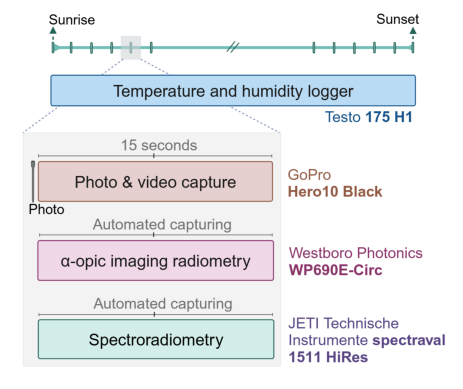

In [21]:
setup_diagram = mpimg.imread(
    os.path.join(data_dir, "Measurement_setup.png")
)

plt.imshow(setup_diagram)
plt.axis('off'); 

## Figure 1-b (Table of measurements)


In [22]:

# Create a modified DataFrame with placeholders for missing view categories
full_data = []
for location in locations:
    for view in views:
        # Filter data for the current location and view category
        subset = merged_wp_jeti_metadata_df[
            (merged_wp_jeti_metadata_df['location'] == location) & (merged_wp_jeti_metadata_df['view'] == view)
        ]
        if subset.empty:
            # Add a placeholder row if no data exists for this location and view
            full_data.append({
                "location": location,
                "view": view,
                "X v,mel,D65 (MEDI) [lx]": np.nan  # Placeholder value
            })
        else:
            # Keep the existing data
            full_data.extend(subset.to_dict('records'))

# Create a complete DataFrame
complete_df = pd.DataFrame(full_data)


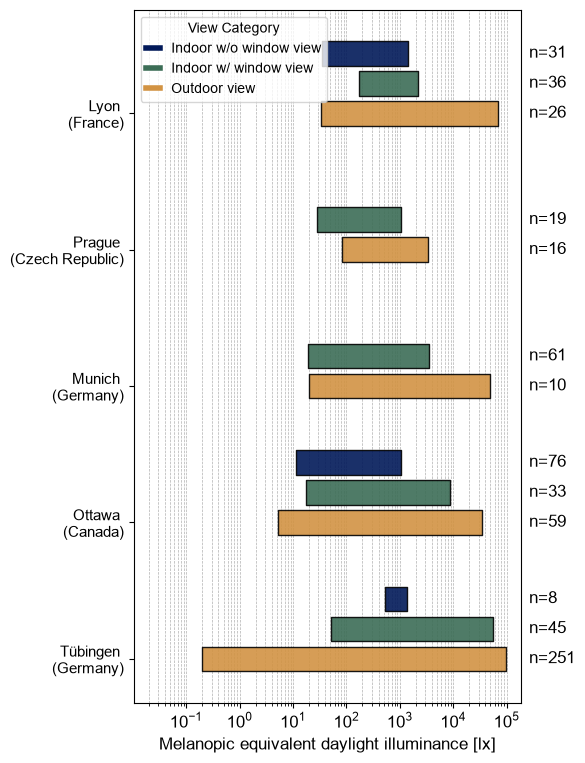

In [23]:
locations = [
    'Tübingen (Germany)',
    'Ottawa (Canada)',
    'Munich (Germany)',
    'Prague (Czech Republic)',
    'Lyon (France)'
]
# Group data by location and view
grouped_data = [
    complete_df[
        (complete_df['location'] == location) & (complete_df['view'] == view)
    ]["X v,mel,D65 (MEDI) [lx]"].dropna().values
    for location in locations
    for view in views
]

# Prepare positions and ranges
offset = 0.22  # Adjust this for spacing
data_to_plot = []
x_positions = []
counts = []
for loc_index, location in enumerate(locations):
    for view_index, view in enumerate(views):
        # Filter data
        view_data = complete_df[
            (complete_df['location'] == location) & (complete_df['view'] == view)
        ]["X v,mel,D65 (MEDI) [lx]"].dropna()

        if view_data.empty:
            # Placeholder for missing category
            x_positions.append(loc_index + view_index * offset)
            data_to_plot.append((0, 0))  # No bar
            counts.append(0)
        else:
            # Add real data
            min_val = view_data.min()
            max_val = view_data.max()
            x_positions.append(loc_index + view_index * offset)
            data_to_plot.append((min_val, max_val - min_val))
            counts.append(len(view_data))
            
# Set up the plot with flipped axes
plt.figure(figsize=(5, 9 ))


# Define a fixed x-position for all annotations to align them in a single line
annotation_x_position = max([start + width for start, width in data_to_plot
                             ]) * 2.7  # Adjust as needed

# Plot as usual, leaving empty spaces where counts are 0
for i, (start, width) in enumerate(data_to_plot):
    if counts[i] == 0:
        continue  # Skip empty bars
    # Determine the view category based on forced order
    view = views[i % len(views)]  # Get the view name based on index
    color = view_color_mapping[view]  # Use the correct color for the category
    
    # Plot the bar
    plt.broken_barh([(start, width)], (x_positions[i] - 0.09, 0.18),
                    facecolors=color, edgecolor='black', alpha=0.9, zorder=3)
     # Annotate with the count of data points, aligned to the right
    plt.text(annotation_x_position,
             x_positions[i],
             f'n={counts[i]}',
             va='center',
             ha='left',
             fontsize=12)

# Create the legend with the forced order
handles = [
    plt.Line2D([0], [0], color=view_color_mapping[view], lw=4, label=f'{view}')
    for view in ['Indoor w/o window view', 'Indoor w/ window view', 'Outdoor view']
]
legend = plt.legend(handles=handles, title="View Category", loc='upper left',
                    bbox_to_anchor=(0, 1), fontsize=10, title_fontsize=10, handlelength=1)

# Modify location labels to split into two lines
formatted_locations = [loc.replace("(", "\n(") for loc in locations]

# Set y-ticks to the formatted locations
plt.yticks(np.arange(len(locations)), formatted_locations, fontsize=11)
plt.xticks(fontsize=12)
# Add labels and title
plt.xlabel("Melanopic equivalent daylight illuminance [lx]", fontsize=12)
plt.grid(True, which='minor', linestyle='--', linewidth=0.5, zorder=0)

# Set the x-axis to a logarithmic scale
plt.xscale('log')
# Add padding to the left side
current_xlim = plt.gca().get_xlim()
plt.gca().set_xlim(left=current_xlim[0] * 0.1, right=current_xlim[1])

# Modify grid and tick settings
plt.grid(True, which='both', axis='x', linestyle='--', linewidth=0.5, zorder=0)  # Both major and minor grids

plt.savefig(
    os.path.join(figures_dir, "broken_bar_plot_mEDI_logscale_location.png"),
    dpi=600,
    bbox_inches="tight"
);

## Figure 1-c (Histogram of overexposed pixels)

In [24]:
# Total number of pixels per image
total_pixels = 9188256

# Initialize the results list
results = []

# Group by the 'view' category
for view, group_df in merged_wp_jeti_metadata_df.groupby('view'):
    # Calculate the overexposed percentage for the current group
    overexposed_percentages = (
        (group_df['overexposed_pixels_Melanopsin'].astype(float) / total_pixels) * 100
    )
    
    # Count the measurements exceeding the thresholds
    over_01_percent = (overexposed_percentages > 0.1).sum()
    over_1_percent = (overexposed_percentages > 1).sum()
    over_10_percent = (overexposed_percentages > 10).sum()
    over_25_percent = (overexposed_percentages > 25).sum()
    
    # Get the timestamps for the measurements with more than 25% overexposed pixels
    timestamps_over_25_percent = group_df['timestamp'][overexposed_percentages > 25].tolist()
    
    # Append the results for this view to the list
    results.append({
        'view': view,
        'over_01_percent_overexposed_pixels': over_01_percent,
        'over_1_percent_overexposed_pixels': over_1_percent,
        'over_10_percent_overexposed_pixels': over_10_percent,
        'over_25_percent_overexposed_pixels': over_25_percent
    })

# Convert the results list into a DataFrame
overexposed_percentage_per_view_df = pd.DataFrame(results)
print(f"This image has more than 25% overexposed pixels: {timestamps_over_25_percent}")

This image has more than 25% overexposed pixels: ['20240322T1530']


In [25]:
overexposed_percentage_per_view_df

,view,over_01_percent_overexposed_pixels,over_1_percent_overexposed_pixels,over_10_percent_overexposed_pixels,over_25_percent_overexposed_pixels
0,Indoor w/ window view,8,5,1,0
1,Indoor w/o window view,0,0,0,0
2,Outdoor view,61,36,19,1


In [26]:
# Save the DataFrame to a CSV file

overexposed_percentage_per_view_df.to_csv(os.path.join(
    tables_dir, 'overexposed_percentage_per_view.csv'),
    sep=',',
    index=True)

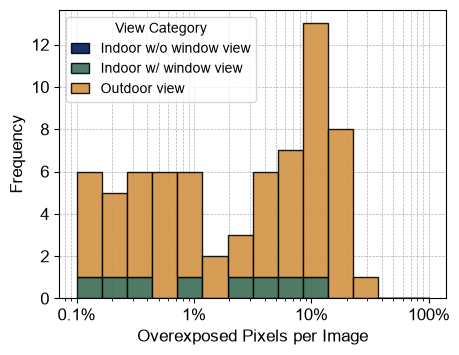

In [27]:
# Total number of pixels per image
total_pixels = 9188256

# Get unique view categories (ensuring consistent color order)
view_categories = sorted(merged_wp_jeti_metadata_df['view'].unique())
colors = {view: cmap_colors[i] for i, view in enumerate(view_categories)}

# Prepare data for stacked histogram
data_to_plot = []
labels = []
color_list = []

# Group by 'view' and create histogram data
for view in view_categories:
    group_df = merged_wp_jeti_metadata_df[merged_wp_jeti_metadata_df['view'] == view]

    # Compute overexposed percentage on-the-fly
    overexposed_percentage = (group_df['overexposed_pixels_Melanopsin'].astype(float) / total_pixels) * 100

    # Exclude values below 0.1%
    filtered_data = overexposed_percentage[overexposed_percentage >= 0.1]

    # Append empty list if no data (to maintain color order)
    data_to_plot.append(filtered_data.values if len(filtered_data) > 0 else [])
    labels.append(view)
    color_list.append(colors[view])

reordered_data_to_plot = [data_to_plot[1], data_to_plot[0], data_to_plot[2]]
reordered_labels = [f'{label}' for label in [labels[1], labels[0], labels[2]]]

bins = np.geomspace(0.1, 100, 15)  # Equal bin sizes in linear space but logarithmic distribution

# Plot stacked histograms
plt.figure(figsize=(5, 3.75))
plt.hist(reordered_data_to_plot,
         bins=bins,
         stacked=True,
         color=color_list,
         edgecolor='black',
         alpha=0.9,
         label=reordered_labels,
         zorder=2)

# Customize the plot
plt.xlabel('Overexposed Pixels per Image', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(title='View Category', prop={'size': 10}, handlelength=1.3, loc='upper left')
plt.grid(True, which='both', linestyle='--', linewidth=0.5, zorder=0)
plt.xscale('log')


# Set custom x-ticks and labels (from 0.1 to 100%)
ticks = [0.1, 1, 10, 100]  # Define ticks
tick_labels = ['0.1%', '1%', '10%', '100%']  # Custom labels for percentage representation

# Apply the custom ticks and labels to the x-axis
plt.xticks(ticks, tick_labels)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
# Add padding to the left side
current_xlim = plt.gca().get_xlim()
#plt.gca().set_xlim(left=current_xlim[0]* 0.2 , right=current_xlim[1]* 2);

plt.savefig(os.path.join(figures_dir, 'Overexposed_pixels_per_view.png'), dpi=600, bbox_inches='tight');

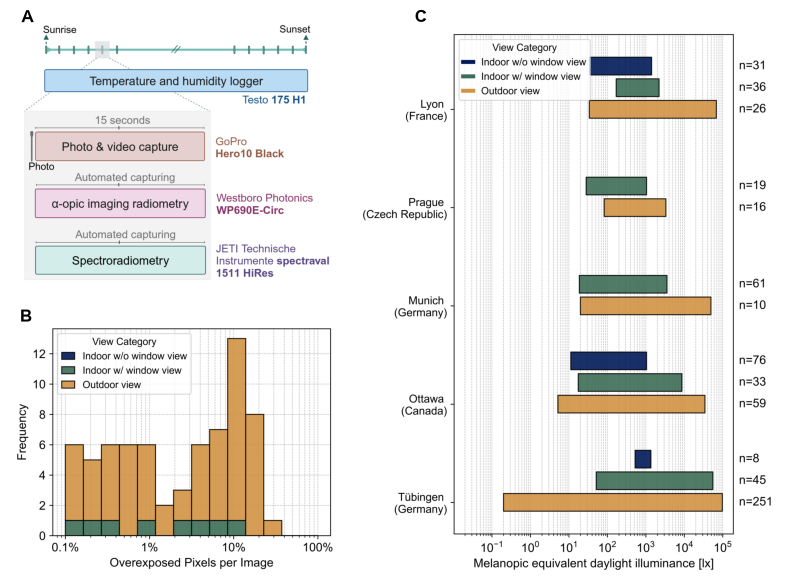

In [34]:
# Figure One

# Create a new figure for combining the plots
combined_fig = plt.figure(figsize=(8, 6))
gs = gridspec.GridSpec(2, 2, width_ratios=[3.5, 4.5], height_ratios=[1, 1])  # Adjust grid for layout

# Load and display the first figure
ax1 = combined_fig.add_subplot(gs[0, 0])  # first row, first column
img1 = mpimg.imread(os.path.join(data_dir, "Measurement_setup.png")) 
ax1.imshow(img1)
ax1.axis('off')  # Hide the axes
ax1.text(0.02, 1, 'A', transform=ax1.transAxes, fontsize=12, fontweight='bold', color='black')

# Load and display the second figure
ax2 = combined_fig.add_subplot(gs[1, 0])  # second row, second column
img2 = mpimg.imread(os.path.join(figures_dir, "Overexposed_pixels_per_view.png"))
ax2.imshow(img2)
ax2.axis('off')  # Hide the axes
ax2.text(0.03, 1, 'B', transform=ax2.transAxes, fontsize=12, fontweight='bold', color='black')


# Load and display the third figure
ax3 = combined_fig.add_subplot(gs[:, 1])  # both rows, second column
img3 = mpimg.imread(os.path.join(figures_dir, 'broken_bar_plot_mEDI_logscale_location.png')) 
ax3.imshow(img3)
ax3.axis('off')  # Hide the axes
ax3.text(0.14, 1.01, 'C', transform=ax3.transAxes, fontsize=12, fontweight='bold', color='black')


# Adjust layout to prevent overlap
plt.tight_layout()

plt.subplots_adjust(hspace=0.1)  
plt.savefig(
    os.path.join(figures_dir, "Figure1.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(figures_dir, "Figure1.pdf"),
    dpi=600,
    bbox_inches="tight"
);


# Figure Two

## Figure 2-a (Scatter plot with marginal histograms)
x axis: Photopic lux, y axis: Melanopic EDI  for each `view` category from `Jeti`

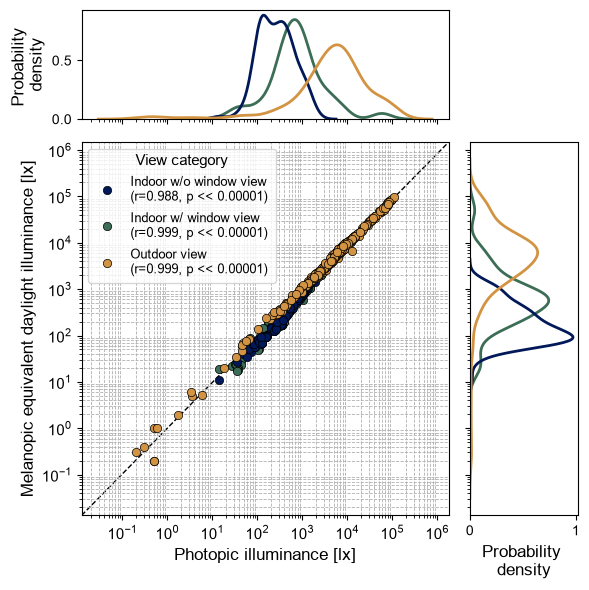

In [49]:
# Probability density and Mel EDI

# Create the figure with gridspec for scatter plot and histograms
fig1 = plt.figure(figsize=(6, 6))
gs = gridspec.GridSpec(4, 4)  # 4x4 grid

# Create the main scatter plot area
ax_main = fig1.add_subplot(gs[1:4, 0:3])

# Create the KDE for the x-axis on top
ax_x_kde = fig1.add_subplot(gs[0, 0:3], sharex=ax_main)

# Create the KDE for the y-axis on the right
ax_y_kde = fig1.add_subplot(gs[1:4, 3], sharey=ax_main)

# Create an empty dictionary to track plotted groups
plotted_groups = {}
# Loop through the groups and plot the scatter points
for group, group_df in merged_wp_jeti_metadata_df.groupby('view'):

    x_values = group_df['Illuminance [lx] (CIE1931 2°)']
    y_values = group_df['X v,mel,D65 (MEDI) [lx]']

    # Calculate the correlation coefficient (r) and p-value
    r, p = stats.pearsonr(x_values, y_values)
    if p < 0.00001:
        label = f"{group} \n(r={r:.3f}, p << 0.00001)"
    else:
        label = f"{group} \n(r={r:.3f}, p={p:.2e})"

    # Scatter plot for each group
    ax_main.scatter(x_values,
                    y_values,
                    label=label,
                    color=view_color_mapping[group],
                    edgecolors='black',
                    linewidth=0.5,
                    zorder=2)
    # Track the group and label for custom legend
    plotted_groups[group] = label  
    
    # KDE plot on the x-axis
    sns.kdeplot(x=x_values,
                ax=ax_x_kde,
                color=view_color_mapping[group],
                log_scale=True,
                linewidth=2)

    # KDE plot on the y-axis, using the `y` argument
    sns.kdeplot(y=y_values,
                ax=ax_y_kde,
                color=view_color_mapping[group],
                log_scale=True,
                linewidth=2)

ax_main.tick_params(axis='x', labelsize=11)
ax_main.tick_params(axis='y', labelsize=11)

# Set labels for the scatter plot
ax_main.set_xlabel('Photopic illuminance [lx]', fontsize=12)
ax_main.set_ylabel('Melanopic equivalent daylight illuminance [lx]',
                   fontsize=12)
ax_main.grid(True, which='minor', linestyle='--', linewidth=0.6, zorder=0)
# Create a custom legend to enforce the order
custom_handles = [
    plt.Line2D(
        [0], [0],
        marker='o',
        color=view_color_mapping[view],
        label=plotted_groups[view],
        markersize=6,
        linestyle='None',
        markeredgecolor='black',
        markeredgewidth=0.5
    )
    for view in ['Indoor w/o window view', 'Indoor w/ window view', 'Outdoor view']
]
ax_main.legend(handles=custom_handles, title="View category",
               loc='upper left',
               title_fontsize=11,
               fontsize=9.5)

# Hide labels for the KDEs (x and y)
ax_x_kde.set_xlabel('')  # Remove x-axis label for top KDE
ax_y_kde.set_ylabel('')  # Remove y-axis label for right KDE

ax_x_kde.tick_params(axis='x', which='both', labelbottom=False,
                     labelsize=12)  # Hide x-axis tick labels for top KDE
ax_y_kde.tick_params(axis='y', which='both', labelleft=False,
                     labelsize=12)  # Hide y-axis tick labels for right KDE

# Set axis labels for both KDEs
ax_x_kde.set_ylabel('Probability \ndensity', fontsize=12, font='Arial')
ax_y_kde.set_xlabel('Probability \ndensity', fontsize=12, font='Arial')

# Ensure log scale is set for the KDEs
ax_x_kde.set_xscale('log')
ax_y_kde.set_yscale('log')
# Add a dashed diagonal line
line = Line2D(
    [0, 1],  # Start and end in normalized figure coordinates (diagonal)
    [0, 1],
    linestyle='--',
    color='black',
    linewidth=1,
    transform=ax_main.transAxes,  # Use Axes coordinate system
    zorder=1)
ax_main.add_line(line)
# Add grid to the KDEs for visibility
#ax_x_kde.grid(True, which='minor', linestyle='--', linewidth=0.6, zorder=0)

#ax_y_kde.grid(True, which='minor', linestyle='--', linewidth=0.6, zorder=0)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "MelEDI_vr_illuminance_logscale_KDE_jeti.png"), dpi=600, bbox_inches="tight");

## Figure 2-b (Scatter plot with marginal histograms)
x axis:  Melanopic EDI from Jeti, y axis: mean melanopic luminance from Westboro for each `view` category (I should calculate melanopic luminance from radiance with the LuxPy package)

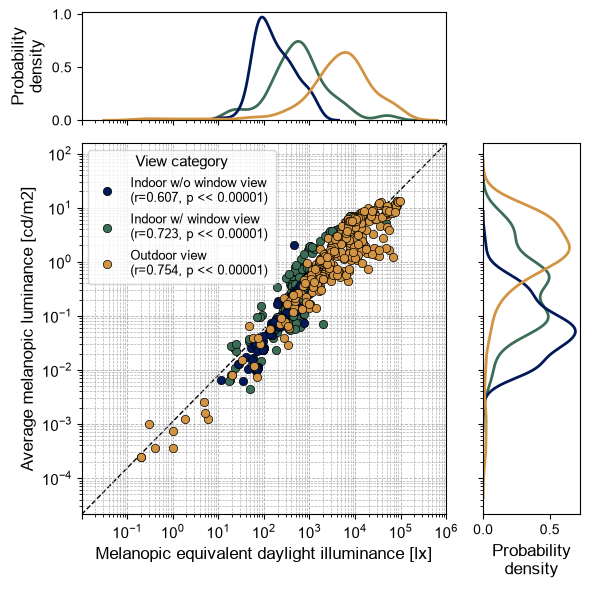

In [63]:
# Create the figure with gridspec for scatter plot and histograms (.replace(0, 1e-3))
fig2 = plt.figure(figsize=(6, 6))
gs = gridspec.GridSpec(4, 4)

# Create the main scatter plot area
ax_main = fig2.add_subplot(gs[1:4, 0:3])

# Create the KDE for the x-axis on top
ax_x_kde = fig2.add_subplot(gs[0, 0:3], sharex=ax_main)

# Create the KDE for the y-axis on the right
ax_y_kde = fig2.add_subplot(gs[1:4, 3], sharey=ax_main)

plotted_groups = {}

# Loop through the groups and plot the scatter points
for group, group_df in merged_wp_jeti_metadata_df.groupby('view'):

    x_values = group_df['X v,mel,D65 (MEDI) [lx]']
    y_values = group_df['average_luminance_Melanopsin']

    r, p = stats.pearsonr(x_values, y_values)

    if p < 0.00001:
        label = f"{group} \n(r={r:.3f}, p << 0.00001)"
    else:
        label = f"{group} \n(r={r:.3f}, p={p:.2e})"

    ax_main.scatter(
        x_values,
        y_values,
        label=label,
        color=view_color_mapping[group],
        edgecolors='black',
        linewidth=0.5,
        zorder=2
    )

    plotted_groups[group] = label

    sns.kdeplot(
        x=x_values,
        ax=ax_x_kde,
        color=view_color_mapping[group],
        log_scale=True,
        linewidth=2
    )

    sns.kdeplot(
        y=y_values,
        ax=ax_y_kde,
        color=view_color_mapping[group],
        log_scale=True,
        linewidth=2
    )

# Set log scale for both x and y axes on the main scatter plot
ax_main.set_xscale('log')
ax_main.set_yscale('log')

# Tick appearance
ax_main.tick_params(axis='x', labelsize=11)
ax_main.tick_params(axis='y', labelsize=11)

# Labels
ax_main.set_xlabel('Melanopic equivalent daylight illuminance [lx]', fontsize=12)
ax_main.set_ylabel('Average melanopic luminance [cd/m2]', fontsize=12)

# Create a custom legend
custom_handles = [
    plt.Line2D(
        [0], [0],
        marker='o',
        color=view_color_mapping[view],
        label=plotted_groups[view],
        markersize=6,
        linestyle='None',
        markeredgecolor='black',
        markeredgewidth=0.5
    )
    for view in [
        'Indoor w/o window view',
        'Indoor w/ window view',
        'Outdoor view'
    ]
]

ax_main.legend(
    handles=custom_handles,
    title='View category',
    loc='upper left',
    title_fontsize=11,
    fontsize=9.5
)

# Hide labels for KDEs
ax_x_kde.set_xlabel('')
ax_y_kde.set_ylabel('')

ax_x_kde.tick_params(
    axis='x',
    which='both',
    labelbottom=False,
    labelsize=12
)

ax_y_kde.tick_params(
    axis='y',
    which='both',
    labelleft=False,
    labelsize=12
)

# KDE labels
ax_x_kde.set_ylabel('Probability\ndensity', fontsize=12, font='Arial')
ax_y_kde.set_xlabel('Probability\ndensity', fontsize=12, font='Arial')

# Ensure log scale for KDEs
ax_x_kde.set_xscale('log')
ax_y_kde.set_yscale('log')

# Diagonal line
line = Line2D(
    [0, 1],
    [0, 1],
    linestyle='--',
    color='black',
    linewidth=1,
    transform=ax_main.transAxes,
    zorder=1
)

ax_main.add_line(line)


ax_main.set_xlim(1e-2, 1e6)

ax_main.set_xticks(
    [1e-2, 1e-1, 1e0, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6]
)

ax_main.set_xticks(
    np.concatenate([
        np.arange(2, 10) * 1e-2,
        np.arange(2, 10) * 1e-1,
        np.arange(2, 10) * 1e0,
        np.arange(2, 10) * 1e1,
        np.arange(2, 10) * 1e2,
        np.arange(2, 10) * 1e3,
        np.arange(2, 10) * 1e4,
        np.arange(2, 10) * 1e5
    ]),
    minor=True
)

labels = ax_main.get_xticklabels()
labels[0].set_visible(False)
ax_main.set_xticklabels(labels)

ax_main.grid(True, which='major', axis='both', linestyle='--', linewidth=0.6)
ax_main.grid(True, which='minor', axis='both', linestyle='--', linewidth=0.5)


plt.tight_layout()

plt.savefig(os.path.join(figures_dir, "Wp_vr_jeti_KDE_logscale.png"), dpi=600, bbox_inches="tight");

## Figure 2-c (Correlation matrix all alpha-opic from Jeti)

In [64]:
#EDI (I neeed to calculate EDI from merged_wp_jeti_metadata_df[['Esc [W/sqm]', 'Emc [W/sqm]', 'Elc [W/sqm]', 'Erh [W/sqm]', 'Emel [W/sqm]']])
corr_matrix = merged_wp_jeti_metadata_df[['Elc [W/sqm]','Emc [W/sqm]','Esc [W/sqm]', 'Erh [W/sqm]', 'Emel [W/sqm]']].corr()
corr_matrix

,Elc [W/sqm],Emc [W/sqm],Esc [W/sqm],Erh [W/sqm],Emel [W/sqm]
Elc [W/sqm],1.000000,0.999883,0.994893,0.999202,0.998698
Emc [W/sqm],0.999883,1.000000,0.996179,0.999679,0.999330
Esc [W/sqm],0.994893,0.996179,1.000000,0.998031,0.998665
Erh [W/sqm],0.999202,0.999679,0.998031,1.000000,0.999934
Emel [W/sqm],0.998698,0.999330,0.998665,0.999934,1.000000


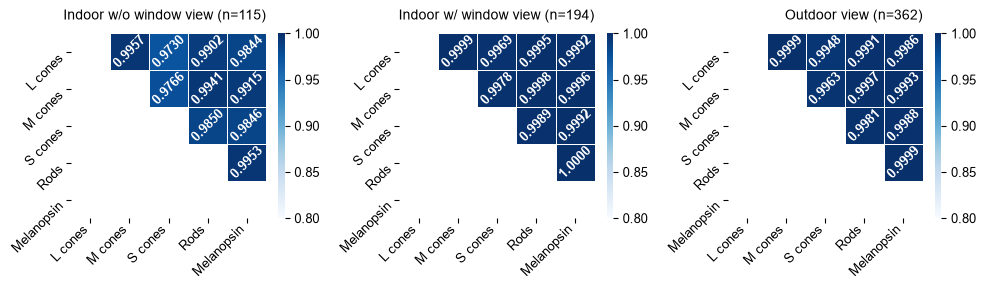

In [66]:

merged_wp_jeti_metadata_df_renamed = merged_wp_jeti_metadata_df.rename(columns={
    'Elc [W/sqm]': 'L cones',
    'Emc [W/sqm]': 'M cones',
    'Esc [W/sqm]': 'S cones', 
    'Erh [W/sqm]': 'Rods', 
    'Emel [W/sqm]': 'Melanopsin'
})
variables = [
    'L cones',
    'M cones',
    'S cones', 
    'Rods', 
    'Melanopsin'
]

# Get unique view categories
views = merged_wp_jeti_metadata_df_renamed['view'].unique()[::-1]

# Set up the figure
fig3 = plt.figure(figsize=(10, 3))
# Get the positions of the ticks for both x and y axes
xticks_pos = np.arange(len(variables))  # Default positions of the ticks
yticks_pos = np.arange(len(variables))  # Default positions of the ticks
# Create subplots for each view category
for i, view in enumerate(views):
    # Filter the DataFrame for the current view category
    view_data = merged_wp_jeti_metadata_df_renamed[merged_wp_jeti_metadata_df_renamed['view'] == view]

    # Calculate the correlation matrix
    corr_matrix_wp = view_data[variables].corr()

    mask = np.tril(np.ones_like(corr_matrix_wp, dtype=bool), k=0)

    # Create a subplot for the correlation matrix
    plt.subplot(1, len(views), i + 1)
    sns.heatmap(
        corr_matrix_wp,
        annot=True,
        fmt=".4f",
        cmap="Blues",
        vmin=0.8,
        vmax=1,
        linewidths=0.7,
        linecolor='white',
        mask=mask,
        annot_kws={'size': 9, 'weight': 'bold', 'rotation': 45},
        cbar_kws={
            'aspect': 30,
            'shrink': 1
        },
    )
    colorbar = plt.gca().collections[0].colorbar
    colorbar.ax.tick_params(labelsize=9)
    colorbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))
    # Add the number of data points (n) in the title
    n_data_points = len(view_data)
    plt.title(f'{view} (n={n_data_points})', pad=10, fontsize=10, loc='right')
    # Get the width of the tick boxes (this will give an idea of their size)
    xtick_width = xticks_pos[1] - xticks_pos[0]  # Difference between two consecutive tick positions (assuming equal spacing)
    ytick_height = yticks_pos[1] - yticks_pos[0]  # Same for y-ticks
    
    # Set the tick labels using the 'variables' list
    plt.xticks(ticks=xticks_pos + xtick_width / 2, labels=variables, rotation=45, ha='right' ,font= "Arial")
    plt.yticks(ticks=yticks_pos + ytick_height / 2, labels=variables, rotation=45, ha='right',font= "Arial" )
    
    ax = plt.gca()
    ax.tick_params(axis='x', labelsize=9, pad=0.1)  # Adjust pad to bring x-axis labels closer
    ax.tick_params(axis='y', labelsize=9, pad=0.1) 
    # Adjust the y-tick label positions
    for label in plt.gca().get_yticklabels():
        label.set_verticalalignment('top')
        
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "Correlation_matrix_α-opics_radiance_per_view.png"), dpi=600, bbox_inches="tight");


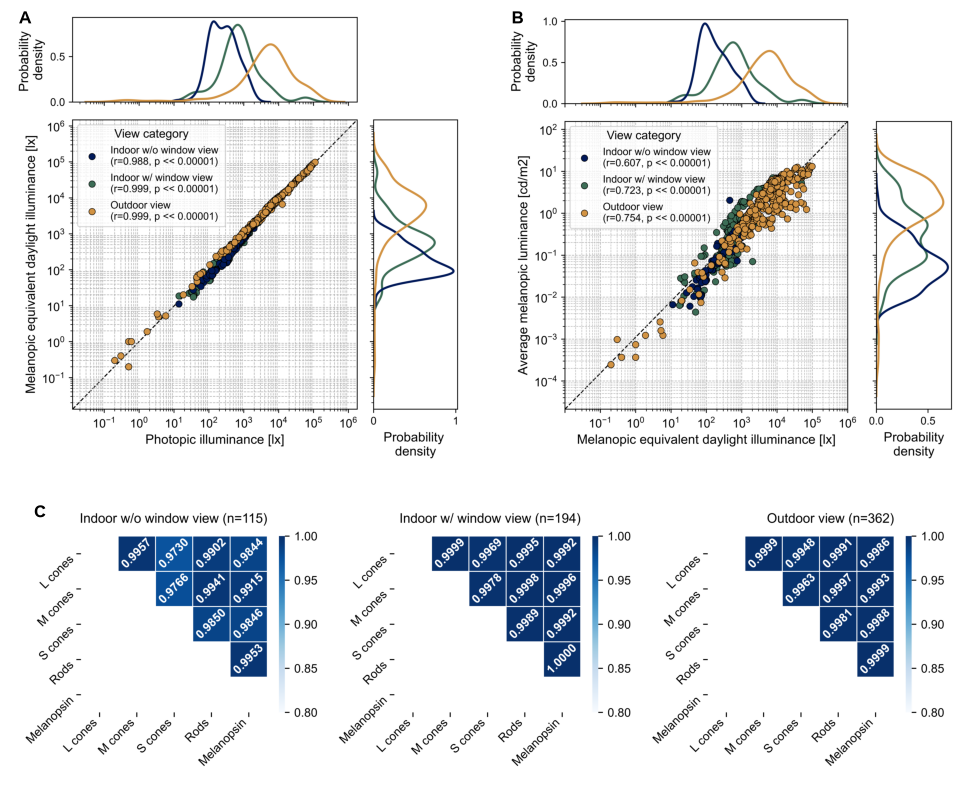

In [67]:
#Figure Two
# Create a new figure for combining the plots
combined_fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(2, 2, height_ratios=[5, 3])  # Create a grid for layout

# Load and display the first figure
ax1 = combined_fig.add_subplot(gs[0, 0])  # First row, first column
img1 = mpimg.imread(os.path.join(figures_dir, "MelEDI_vr_illuminance_logscale_KDE_jeti.png"))
ax1.imshow(img1)
ax1.axis('off')  # Hide the axes
ax1.text(0.02, 0.97, 'A', transform=ax1.transAxes, fontsize=12, fontweight='bold', color='black')


# Load and display the second figure
ax2 = combined_fig.add_subplot(gs[0, 1])  # First row, second column
img2 = mpimg.imread(os.path.join(figures_dir, "Wp_vr_jeti_KDE_logscale.png"))
ax2.imshow(img2)
ax2.axis('off')  # Hide the axes
ax2.text(0.02, 0.97, 'B', transform=ax2.transAxes, fontsize=12, fontweight='bold', color='black')


# Load and display the third figure
ax3 = combined_fig.add_subplot(gs[1, :])  # Second row, spanning two columns
img3 = mpimg.imread(os.path.join(figures_dir, "Correlation_matrix_α-opics_radiance_per_view.png")) 
ax3.imshow(img3)
ax3.axis('off')  # Hide the axes
ax3.text(0.02, 0.95, 'C', transform=ax3.transAxes, fontsize=12, fontweight='bold', color='black')


# Adjust layout to prevent overlap
plt.tight_layout()

plt.subplots_adjust(hspace=0.1)  
plt.savefig(os.path.join(figures_dir, "Figure2.png"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(figures_dir, "Figure2.pdf"), dpi=600, bbox_inches="tight");


# Figure Three

## Figure 3-a (Correlation matrix all average radiance α-opics from Westboro)

In [68]:
corr_matrix_wp_average = merged_wp_jeti_metadata_df.filter(like='average_radiances').corr()
corr_matrix_wp_average

,average_radiances_L cones,average_radiances_M cones,average_radiances_S cones,average_radiances_Rods,average_radiances_Melanopsin
average_radiances_L cones,1.000000,0.956752,0.937844,0.988199,0.978669
average_radiances_M cones,0.956752,1.000000,0.991958,0.920191,0.986640
average_radiances_S cones,0.937844,0.991958,1.000000,0.906516,0.978191
average_radiances_Rods,0.988199,0.920191,0.906516,1.000000,0.954491
average_radiances_Melanopsin,0.978669,0.986640,0.978191,0.954491,1.000000


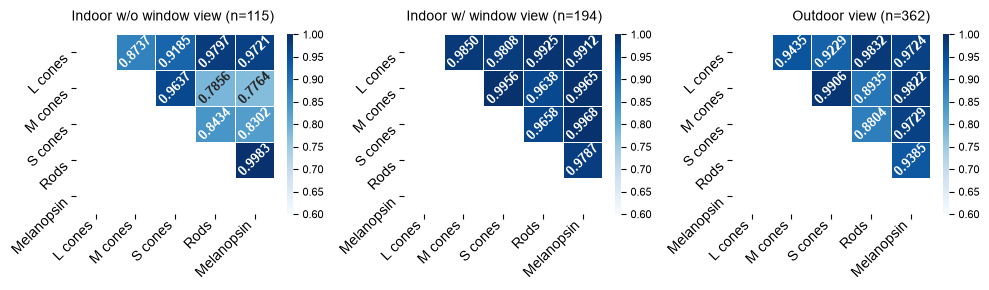

In [69]:

n_data_points_dict = {}
# Set up the figure
plt.figure(figsize=(10, 3))

# Create subplots for each view category
for i, view in enumerate(views):
    # Filter the DataFrame for the current view category
    view_data = merged_wp_jeti_metadata_df[merged_wp_jeti_metadata_df['view'] == view]

    # Calculate the correlation matrix for columns starting with 'average'
    corr_matrix_wp = view_data.filter(like='average_radiances').corr()

    mask = np.tril(np.ones_like(corr_matrix_wp, dtype=bool), k=0)

    # Create a subplot for the correlation matrix
    plt.subplot(1, len(views), i + 1)
    sns.heatmap(
        corr_matrix_wp,
        annot=True,
        fmt=".4f",
        cmap="Blues",
        vmin=0.6,
        vmax=1,
        linewidths=0.7,
        linecolor='white',
        mask=mask,
        annot_kws={'size': 9, 'weight':'bold', 'rotation': 45},
        cbar_kws={
            'aspect': 30,
            'shrink': 1
        },
        xticklabels=[name.split('_')[-1] for name in corr_matrix_wp.columns],
        yticklabels=[name.split('_')[-1] for name in corr_matrix_wp.index])
    colorbar = plt.gca().collections[0].colorbar
    colorbar.ax.tick_params(labelsize=8)

    # Add the number of data points (n) in the title
    n_data_points = len(view_data)
    plt.title(f'{view} (n={n_data_points})', pad=10, fontsize=10, loc='right')
    n_data_points_dict[view] = n_data_points
    # Set tick parameters for both axes to ensure proximity and font size
    plt.gca().tick_params(axis='x', labelsize=9, pad=0.1)  # Adjust `pad` for x-axis
    plt.gca().tick_params(axis='y', labelsize=9, pad=0.1)  # Adjust `pad` for y-axis

    # Adjust x and y ticks: font size and alignment to the tick marks
    plt.xticks(rotation=45, ha='right',fontsize=10)  # X-tick labels end aligned at tick
    plt.yticks(rotation=45, va='top', fontsize=10)    # Y-tick labels end aligned at tick
    plt.tight_layout()

plt.savefig(os.path.join(figures_dir, "Correlation_matrix_α-opics_average_radiances_per_view.png"), dpi=600, bbox_inches="tight");

## Correlation of pixel by pixel

In [70]:
# Read Dataframe we generated from "WP_derivatives" notebook

average_pixels_correlation_df = pd.read_csv(
    os.path.join(tables_dir, "average_pixels_correlation_df.csv")
)


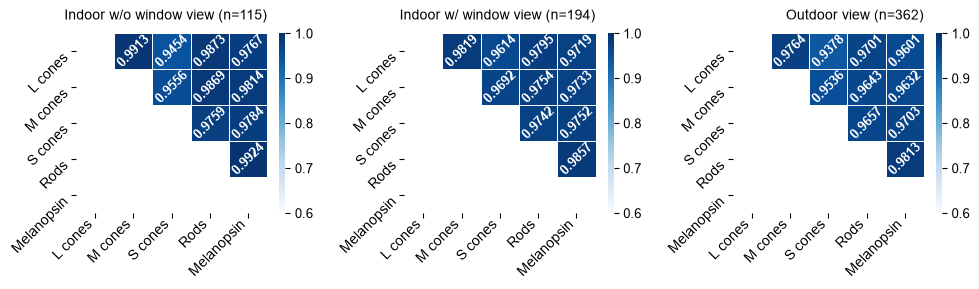

In [71]:
# Unique categories from the data
pixels_views = average_pixels_correlation_df['view'].unique()[::-1]

# Create a figure for subplots
plt.figure(figsize=(10, 3))

# Loop through each view and plot its correlation matrix
for i, view in enumerate(pixels_views):
    # Filter and pivot data for the current view
    category_data = average_pixels_correlation_df[average_pixels_correlation_df['view'] == view]
    corr_matrix_wp = category_data.pivot(index='Row', columns='Column', values='Value')
    # Ensure the tick order
    ordered_ticks = ['L cones', 'M cones', 'S cones', 'Rods', 'Melanopsin']
    corr_matrix_wp = corr_matrix_wp.loc[ordered_ticks, ordered_ticks]
    
    # Create mask for lower triangle
    mask = np.tril(np.ones_like(corr_matrix_wp, dtype=bool), k=0)
    
    # Create a subplot for the correlation matrix
    plt.subplot(1, len(pixels_views), i + 1)
    sns.heatmap(
        corr_matrix_wp,
        annot=True,
        fmt=".4f",
        cmap="Blues",
        vmin=0.6,
        vmax=1,
        linewidths=0.7,
        linecolor='white',
        mask=mask,
        annot_kws={'size': 9, 'weight':'bold', 'rotation': 45},
        cbar_kws={
            'aspect': 30,
            'shrink': 1
        },
        xticklabels=ordered_ticks, 
        yticklabels=ordered_ticks 
    )
    # Remove axis labels explicitly
    plt.xlabel("")
    plt.ylabel("")
    
    # Customize colorbar
    colorbar = plt.gca().collections[0].colorbar
    colorbar.ax.tick_params(labelsize=9)
    
    # Set title for each subplot
    plt.title(f'{view} (n={[115, 194, 362][i]})', pad=10, fontsize=10, loc='right')
    
    # Set tick parameters for both axes
    plt.gca().tick_params(axis='x', labelsize=9, pad=0.1)
    plt.gca().tick_params(axis='y', labelsize=9, pad=0.1)
    
    # Adjust ticks alignment
    plt.xticks(rotation=45, ha='right',fontsize=10)  # Align x-tick labels
    plt.yticks(rotation=45, va='top',fontsize=10)    # Align y-tick labels

# Ensure layout fits well
plt.tight_layout()

plt.savefig(os.path.join(figures_dir, "Correlation_matrix_α-opics_pixel_by_pixel_per_view.png"), dpi=600, bbox_inches="tight");

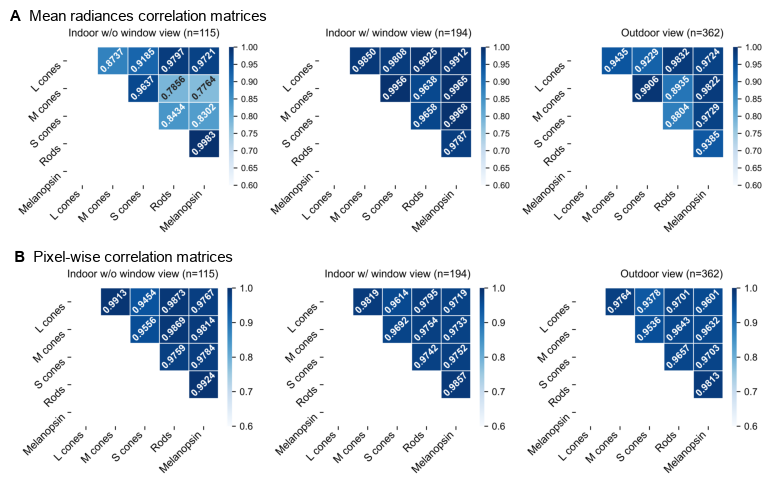

In [72]:
# Figure Three

# Create a figure with the specified size
combined_fig = plt.figure(figsize=(10, 6))

# Define the grid layout: 2 rows and 2 columns, with adjusted height and width ratios
gs = gridspec.GridSpec(
    2,
    1,
    height_ratios=[1, 1]
)

# Load and display the first figure
ax1 = combined_fig.add_subplot(gs[0, 0]) 
img1 = mpimg.imread(os.path.join(figures_dir, 'Correlation_matrix_α-opics_average_radiances_per_view.png'))
ax1.imshow(img1)
ax1.axis('off')  # Hide the axes
ax1.text(0.0, 1, 'A', transform=ax1.transAxes, fontsize=11, fontweight='bold', color='black')
ax1.text(0.02, 1, ' Mean radiances correlation matrices', transform=ax1.transAxes, fontsize=11, fontweight='normal', color='black')

# Load and display the second figure
ax2 = combined_fig.add_subplot(gs[1, 0])  
img2 = mpimg.imread(os.path.join(figures_dir, 'Correlation_matrix_α-opics_pixel_by_pixel_per_view.png'))
ax2.imshow(img2)
ax2.axis('off')  # Hide the axes
ax2.text(0.0, 1, 'B', transform=ax2.transAxes, fontsize=11, fontweight='bold', color='black')
ax2.text(0.02, 1, ' Pixel-wise correlation matrices', transform=ax2.transAxes, fontsize=11, fontweight='normal', color='black')

# Adjust layout to prevent overlap between the subplots and ensure they fit tightly
plt.subplots_adjust(wspace=0.05, hspace=0.09)  # Reduce space between subplots
plt.savefig(os.path.join(figures_dir, "Figure3.png"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(figures_dir, "Figure3.pdf"), dpi=600, bbox_inches="tight");

# Figure Four

## Figure 4-a (Histogram of RMS contrast by scene category (different colors))

C:\Users\ntabandeh\AppData\Local\Temp\ipykernel_10204\2976129717.py:49: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  parts = plt.violinplot(data_to_plot,


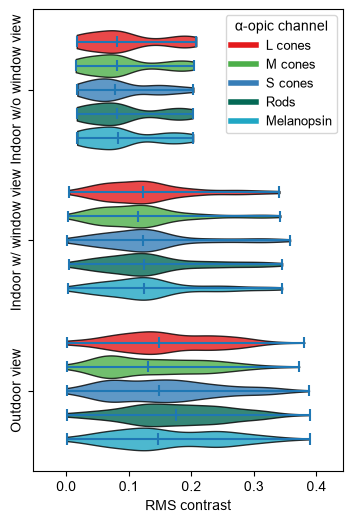

In [73]:
# Filter the columns based on the prefix 'rms'
rms_columns = [
    col for col in merged_wp_jeti_metadata_df.columns if col.startswith('rms')
]

# Create a figure
plt.figure(figsize=(4, 6))

rms_columns_ordered = [
    col for photoreceptor in photoreceptor_colors.keys()
    for col in rms_columns
    if col.split('_')[2] == photoreceptor
]
# Map each RMS column to its corresponding color using photoreceptor name
colors = [
    photoreceptor_colors[col.split('_')[2]]  # Extract photoreceptor part and get color
    for col in rms_columns
]

# Prepare data for the violin plots
data_to_plot = []
y_positions = []
color_map = {}  # To store colors for each RMS column based on photoreceptor

# Offset for positioning the violins
offset = 0.16  # Adjust this for spacing
num_metrics = len(rms_columns)

# Loop through each view category
for view_index, view in enumerate(views):
    # Filter data for the current view category
    view_data = merged_wp_jeti_metadata_df[merged_wp_jeti_metadata_df['view'] == view]

    for i, col in enumerate(rms_columns):
        # Prepare data for each RMS column
        column_data = view_data[col].dropna().values

        if len(column_data) > 0:  # Only if there's data to plot
            data_to_plot.append(column_data)
            # Position each violin slightly offset from the view index
            y_positions.append(view_index +
                               (i * offset))  # Add offset for each metric

            # Assign color based on photoreceptor
            photoreceptor = col.split('_')[2]  # Extract and lowercase photoreceptor name
            color_map[col] = photoreceptor_colors[photoreceptor]  # Map color

# Create the violin plot with flipped axes
parts = plt.violinplot(data_to_plot,
                       positions=y_positions,
                       showmedians=True,
                       widths=0.15,
                       vert=False)  # Set vert=False for horizontal plot

# Customize the violins
for i, pc in enumerate(parts['bodies']):
    # Get the column for this violin and the corresponding color
    column_name = rms_columns[i % len(rms_columns)]
    color = color_map[column_name]

    # Set violin properties
    pc.set_facecolor(color)  # Set color from color map
    pc.set_edgecolor('black')  # Set edge color of the violins
    pc.set_alpha(0.8)  # Set transparency

# Calculate the y-tick positions to center them
tick_positions = [
    np.mean([y_positions[i], y_positions[i + len(rms_columns) - 1]])
    for i in range(0, len(y_positions), len(rms_columns))
]

# Adding labels and title
plt.yticks(ticks=tick_positions,
           labels=[f"{v}" for v in views],
           rotation=90,
           va='center')
plt.gca().invert_yaxis()
plt.yticks(fontsize=10)
plt.xlabel("RMS contrast",fontsize=10)

# Get current x-axis limits
x_min, x_max = plt.gca().get_xlim()

# Define padding (adjust this value as needed)
padding = (x_max - x_min) * 0.08  # 5% of the current range

# Set new x-axis limits to add space on both sides
plt.xlim(x_min - padding, x_max + padding)

# Create legend using photoreceptor names and their colors
handles = [
    plt.Line2D([0], [0], color=color, lw=4, label=photoreceptor.capitalize())
    for photoreceptor, color in photoreceptor_colors.items()
]
plt.legend(handles=handles,
           title='α-opic channel',
           loc='upper right',
           title_fontsize=10,
           fontsize=9)

plt.savefig(os.path.join(figures_dir, "Violin_plot_rms_contrast_per_view_flip.png"), dpi=600, bbox_inches="tight");


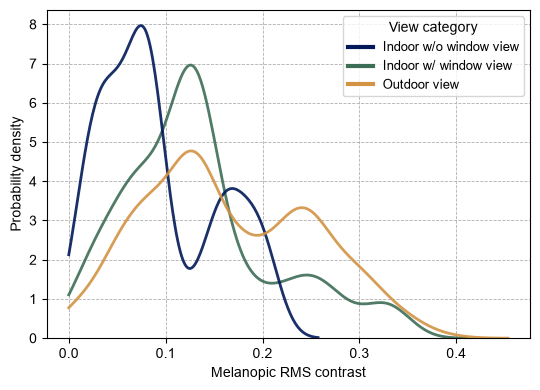

In [74]:
# Density plot for ipRGC

# Initialize the plot
plt.figure(figsize=(5.5, 4))

# Loop through each group in the DataFrame grouped by 'view'
for view, group_df in merged_wp_jeti_metadata_df.groupby('view'):
    sns.kdeplot(data=group_df['rms_contrast_Melanopsin'], 
                label=view, 
                fill=False,
                color=view_color_mapping[view],  
                alpha=0.9,
                bw_adjust=0.8,
                linewidth=2,
                clip=(0, None),  # Clip to prevent negative values
                zorder=2)


custom_handles = [
    plt.Line2D(
        [0], [0],
        color=view_color_mapping[view],
        label=view,
        lw=3  # Set line width to make it thicker,
    )
    for view in ['Indoor w/o window view', 'Indoor w/ window view', 'Outdoor view']
]

# Set labels and title
plt.xlabel('Melanopic RMS contrast')
plt.ylabel('Probability density')
#plt.title('Density Plot of Invalid Pixels by View Category')
plt.legend( handles=custom_handles, title='View category', fontsize=9, title_fontsize=10)
plt.grid(True, linestyle='--', linewidth=0.6, zorder = 0)

# Show the plot
plt.tight_layout()

## Figure 4-b (Scatter plot with marginal histograms)
x axis: Melanopic EDL  y axis: RMS contrast

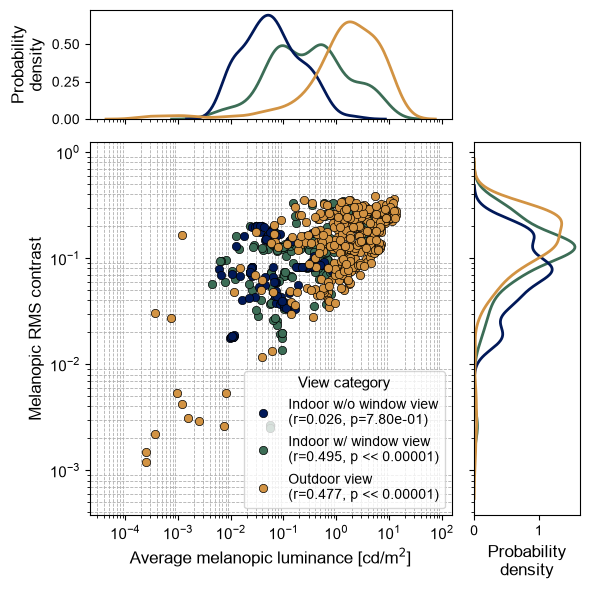

In [75]:
# Create the figure with gridspec for scatter plot and histograms (.replace(0, 1e-3))
fig = plt.figure(figsize=(6, 6))
gs = gridspec.GridSpec(4, 4)  # 4x4 grid


# Create the main scatter plot area
ax_main = fig.add_subplot(gs[1:4, 0:3])

# Create the KDE for the x-axis on top
ax_x_kde = fig.add_subplot(gs[0, 0:3], sharex=ax_main)

# Create the KDE for the y-axis on the right
ax_y_kde = fig.add_subplot(gs[1:4, 3], sharey=ax_main)

plotted_groups = {}
# Loop through the groups and plot the scatter points
for group, group_df in merged_wp_jeti_metadata_df.groupby('view'):
    
    x_values = group_df['average_luminance_Melanopsin']
    y_values = group_df['rms_contrast_Melanopsin']
     # Calculate the correlation coefficient (r) and p-value
    r, p = stats.pearsonr(x_values, y_values) 
    
    if p < 0.00001:
        label = f"{group}\n(r={r:.3f}, p << 0.00001)"
    else:
        label = f"{group}\n(r={r:.3f}, p={p:.2e})"
    
    # Scatter plot for each group
    ax_main.scatter(x_values, y_values, label=label, color=view_color_mapping[group], edgecolors='black', linewidth=0.5, zorder = 2)
    plotted_groups[group] = label
    # KDE plot on the x-axis
    sns.kdeplot(x=x_values, ax=ax_x_kde, color=view_color_mapping[group], log_scale=True, linewidth=2, label=group)

    # KDE plot on the y-axis, using the `y` argument
    sns.kdeplot(y=y_values, ax=ax_y_kde, color=view_color_mapping[group], log_scale=True, linewidth=2)

# Set log scale for both x and y axes on the main scatter plot
ax_main.set_xscale('log')
ax_main.set_yscale('log')
ax_main.tick_params(axis='x', labelsize=11)  
ax_main.tick_params(axis='y', labelsize=11)

# Set labels for scatter plot
ax_main.set_xlabel('Average melanopic luminance [cd/m$^2$]', fontsize=12)
ax_main.set_ylabel('Melanopic RMS contrast', fontsize=12)
ax_main.grid(True, which='minor', linestyle='--', linewidth=0.6, zorder=0)
# Create a custom legend to enforce the order
custom_handles = [
    plt.Line2D(
        [0], [0],
        marker='o',
        color=view_color_mapping[view],
        label=plotted_groups[view],
        markersize=6,
        linestyle='None',
        markeredgecolor='black',
        markeredgewidth=0.5
    )
    for view in ['Indoor w/o window view', 'Indoor w/ window view', 'Outdoor view']]
ax_main.legend( handles = custom_handles, title="View category", loc='lower right', title_fontsize=11, fontsize = 10)

# Hide labels for the KDEs (x and y)
ax_x_kde.set_xlabel('')  # Remove x-axis label for top KDE
ax_y_kde.set_ylabel('')  # Remove y-axis label for right KDE

# Hide the ticks on the marginal KDEs
# ax_x_kde.tick_params(axis='x', which='both', length=0)
# ax_y_kde.tick_params(axis='y', which='both', length=0)

# Hide labels and ticks for the KDEs
plt.setp(ax_x_kde.get_xticklabels(), visible=False)
plt.setp(ax_y_kde.get_yticklabels(), visible=False)
ax_x_kde.set_ylabel('Probability\ndensity', fontsize=12, font = "Arial")
ax_y_kde.set_xlabel('Probability\ndensity', fontsize=12, font = "Arial")

# Ensure log scale is set for the KDEs
ax_x_kde.set_xscale('log')
ax_y_kde.set_yscale('log')
# Add grid to the KDEs for visibility
#ax_x_kde.grid(True, which='minor', linestyle='--', linewidth=0.6)
#ax_y_kde.grid(True, which='minor', linestyle='--', linewidth=0.6)

plt.tight_layout()

plt.savefig(os.path.join(figures_dir, "RMS_vr_luminance_KDE_logscale_WP.png"), dpi=600, bbox_inches="tight");

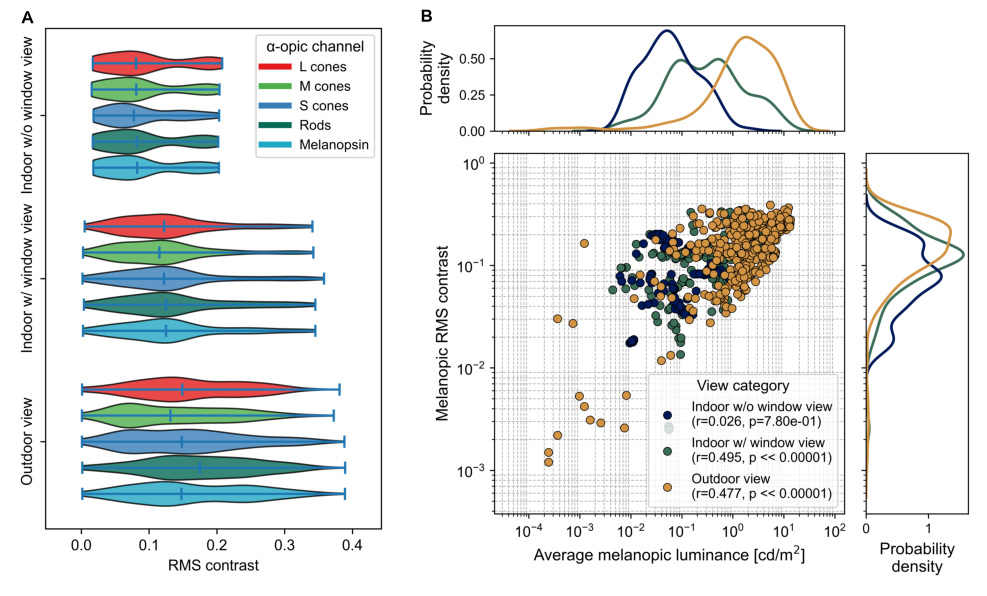

In [76]:
#Figure Four

# Create a figure with the specified size
combined_fig = plt.figure(figsize=(10, 6))

# Define the grid layout: 1 rows and 2 columns with different ratios for each grid cell
gs = gridspec.GridSpec(
    1, 2 , width_ratios=[2, 3]
)

# Load and display the third figure (Image C)
ax1 = combined_fig.add_subplot(gs[0, 0])  # Second row, first column (6*4)
img1 = mpimg.imread(os.path.join(figures_dir, "Violin_plot_rms_contrast_per_view_flip.png"))
ax1.imshow(img1)
ax1.axis('off')  # Hide the axes
ax1.text(0.03, 0.99, 'A', transform=ax1.transAxes, fontsize=12, fontweight='bold', color='black')

# Load and display the fourth figure (Image D)
ax2 = combined_fig.add_subplot(gs[0, 1])  # First row, second column (6*6)
img2 = mpimg.imread(os.path.join(figures_dir, "RMS_vr_luminance_KDE_logscale_WP.png"))
ax2.imshow(img2)
ax2.axis('off')  # Hide the axes
ax2.text(0.02, 0.99, 'B', transform=ax2.transAxes, fontsize=12, fontweight='bold', color='black')
plt.tight_layout()
# Adjust layout to prevent overlap and fit images tightly
#plt.subplots_adjust(wspace=0.01, hspace=0.1)  # Reduce space between subplots

plt.savefig(os.path.join(figures_dir, "Figure4.png"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(figures_dir, "Figure4.pdf"), dpi=600, bbox_inches="tight");

# Figure Five

## Figure 5 (Example of a low/ high contrast scenes for each view categories)

In [77]:
# Loop through each view category
for view in views:
    print(f"\nView Category: {view}")
    
    # Filter the DataFrame for the current view category
    category_df = merged_wp_jeti_metadata_df[merged_wp_jeti_metadata_df['view'] == view]
    
    # Sort the filtered DataFrame by 'rms_contrast_Melanopsin'
    sorted_df = category_df.sort_values('rms_contrast_Melanopsin').reset_index(drop=True)
    
    # Number of points to select 
    num_points = 5
    
    # Calculate step size
    step = max(1, len(sorted_df) // (num_points - 1))
    
    # Select indices at equal intervals
    selected_indices = [i * step for i in range(num_points)]
    # Ensure the last index is included
    if selected_indices[-1] >= len(sorted_df):
        selected_indices[-1] = len(sorted_df) - 1
    
    # Print the selected values and three surrounding timestamps for the current view
    print("Selected RMS Contrast Values and Their Timestamps with Surrounding Timestamps:")
    for idx in selected_indices:
        selected_value = sorted_df.loc[idx, 'rms_contrast_Melanopsin']
        # Get three timestamps around the selected index
        start = max(idx - 1, 0)
        end = min(idx + 2, len(sorted_df))
        surrounding_timestamps = sorted_df.loc[start:end-1, 'timestamp'].tolist()
        print(f"RMS Contrast: {selected_value} at Timestamps: {surrounding_timestamps}")


View Category: Indoor w/o window view
Selected RMS Contrast Values and Their Timestamps with Surrounding Timestamps:
RMS Contrast: 0.0175 at Timestamps: ['20231120T1700', '20231120T1400']
RMS Contrast: 0.0432 at Timestamps: ['20231122T1030', '20231122T1130', '20230612T1700']
RMS Contrast: 0.082 at Timestamps: ['20230612T1000', '20230621T1230', '20230616T1500']
RMS Contrast: 0.1458 at Timestamps: ['20230404T1500', '20230404T1430', '20230613T0830']
RMS Contrast: 0.2025 at Timestamps: ['20230626T1230', '20230626T1330', '20230626T1030']

View Category: Indoor w/ window view
Selected RMS Contrast Values and Their Timestamps with Surrounding Timestamps:
RMS Contrast: 0.0025 at Timestamps: ['20231114T1700', '20231114T1630']
RMS Contrast: 0.0764 at Timestamps: ['20230614T1200', '20230803T1700', '20230619T0800']
RMS Contrast: 0.1244 at Timestamps: ['20230310T1300', '20231022T0900', '20231121T1300']
RMS Contrast: 0.1555 at Timestamps: ['20231022T1600', '20231022T1630', '20231022T1800']
RMS Cont

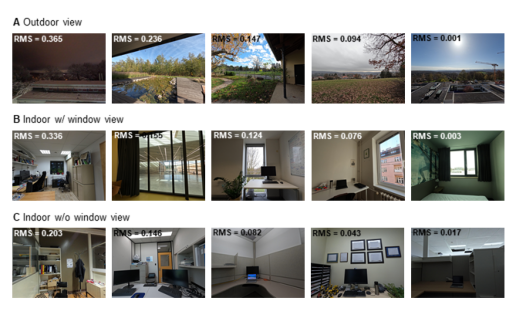

In [78]:
# Aligned selected images in PowerPoint 

img_contrast_example = mpimg.imread(os.path.join(data_dir, "Figure5.png"))

plt.imshow(img_contrast_example)
plt.axis('off');  # Turn off axis if you want a cleaner display
plt.savefig(os.path.join(figures_dir, "Figure5.png"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(figures_dir, "Figure5.pdf"), dpi=600, bbox_inches="tight")

# Figure Six 

In [80]:
# Function to calculate and plot α-opics amplitude spectra

def plot_amplitude_spectra_with_fit(npz_file_path, ax=None):
     # Define new key names for the photoreceptor channels
    new_key_names = ["L cones", "M cones", "S cones", "Rods", "Melanopsin"]
    if ax is None:
        ax = plt.gca()
    # Load images from the .npz file
    with np.load(npz_file_path) as npz_file:
        keys = list(npz_file.keys())[:5]  # First five keys
        images = [npz_file[key] for key in keys]
    
    # Iterate over the images and corresponding photoreceptor names
    for image, new_key in zip(images, new_key_names):
        # Compute the amplitude spectrum
        amplitude_spectra = scenes_functions.compute_amplitude_spectrum(image)
        
        # Compute the radial frequencies and amplitudes
        radial_frequencies, radial_amplitudes = scenes_functions.radial_frequencies_logarithmically_spaced(amplitude_spectra)
        
        # Scatter plot for the amplitude spectrum
        ax.scatter(
            radial_frequencies,
            radial_amplitudes,
            color=photoreceptor_colors[new_key],
            zorder=2
        )
        
        # Perform linear regression in log-log space
        valid_indices = radial_amplitudes > 0  # Ensure valid data
        log_frequencies = np.log10(radial_frequencies[valid_indices])
        log_amplitudes = np.log10(radial_amplitudes[valid_indices])
        
        if len(log_frequencies) > 1:  # Check if regression is possible
            slope, intercept, r_value, p_value, std_err = linregress(log_frequencies, log_amplitudes)
            
            # Generate the regression line
            fitted_amplitudes = (10 ** intercept) * (radial_frequencies ** slope)
            
            # Format the regression line label
            if p_value < 0.00001:
                label = f"{new_key}  r= {r_value:.3f}, p << 0.00001"
            else:
                label = f"{new_key}  r= {r_value:.3f}, p={p_value:.2e}"
             
            # Plot the regression line
            ax.plot(
                radial_frequencies,
                fitted_amplitudes,
                label=label,
                linestyle='--',
                color=photoreceptor_colors[new_key],
                linewidth=1.5,
                zorder=3
            )
        else:
            print(f"Not enough valid data for regression in image {new_key}")
    
    # Set axes to log scale
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.set_xlabel('Spatial frequency (cycle/image)', fontsize=13)
    ax.set_ylabel('Amplitude', fontsize=13)
    # Set y-axis limits
    ax.set_ylim(top=1e6)  # Ensure the upper limit is 10^6
    # Add legend with thicker lines
    handles, labels = ax.get_legend_handles_labels()
    thicker_handles = [
        plt.Line2D([0], [0], color=handle.get_color(), linestyle='--', lw=2, label=label)
        for handle, label in zip(handles, labels)
    ]
    # Add legend and grid
    ax.legend(handles=thicker_handles, title="α-opic channel", fontsize=10, title_fontsize=11, loc='best')
    ax.grid(True, which='minor', linestyle='--', linewidth=0.6, zorder=0)
    
    # Adjust layout
    plt.tight_layout()

In [81]:
# Function to calculate and plot composite amplitude spectra

def plot_composite_amplitude_spectra(npz_file_path, ax=None):
    composite_key_names = ["L+M+S", "L-M", "S-(L+M)"]
    if ax is None:
        ax = plt.gca()
    # Load images from the .npz file
    with np.load(npz_file_path) as npz_file:
        keys = list(npz_file.keys())[:5]  # First five keys
        images = [npz_file[key] for key in keys]

    # Create the composite arrays
    composite_arrays = {
        "L+M+S": images[0] + images[1] + images[2],  # L + M + S
        "L-M": images[0] - images[1],               # L - M
        "S-(L+M)": images[2] - (images[0] + images[1])  # S - (L + M)
    }

    # Iterate over the composite arrays and their names
    for composite_name, composite_array in composite_arrays.items():
        # Compute the amplitude spectrum
        amplitude_spectrum = scenes_functions.compute_amplitude_spectrum(composite_array)
        
        # Compute the radial frequencies and amplitudes
        radial_frequencies, radial_amplitudes = scenes_functions.radial_frequencies_logarithmically_spaced(amplitude_spectrum)
        
        # Scatter plot for the amplitude spectrum
        ax.scatter(
            radial_frequencies,
            radial_amplitudes,
            zorder=2
        )
        
        # Perform linear regression in log-log space
        valid_indices = radial_amplitudes > 0  # Ensure valid data
        log_frequencies = np.log10(radial_frequencies[valid_indices])
        log_amplitudes = np.log10(radial_amplitudes[valid_indices])
        
        if len(log_frequencies) > 1:  # Check if regression is possible
            slope, intercept, r_value, p_value, std_err = linregress(log_frequencies, log_amplitudes)
            
            # Generate the regression line
            fitted_amplitudes = (10 ** intercept) * (radial_frequencies ** slope)
            
            # Format the regression line label
            if p_value < 0.00001:
                label = f"{composite_name} r= {r_value:.3f}, p << 0.00001"
            else:
                label = f"{composite_name} r= {r_value:.3f}, p={p_value:.2e}"
            
            # Plot the regression line
            ax.plot(
                radial_frequencies,
                fitted_amplitudes,
                label=label,
                linestyle='--',
                linewidth=1.5,
                zorder=3
            )
        else:
            print(f"Not enough valid data for regression in composite array {composite_name}")
    
    # Set axes to log scale
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.set_xlabel('Spatial frequency (cycle/image)', fontsize=13)
    ax.set_ylabel('Amplitude', fontsize=13)
    # Set y-axis limits
    ax.set_ylim(top=1e6)  # Ensure the upper limit is 10^6
    # Add legend with thicker lines
    handles, labels = ax.get_legend_handles_labels()
    thicker_handles = [
        plt.Line2D([0], [0], color=handle.get_color(), linestyle='--', lw=2, label=label)
        for handle, label in zip(handles, labels)
    ]
    # Add legend and grid
    ax.legend(handles=thicker_handles, title="Composite channel", fontsize=10, title_fontsize=11, loc='best')
    ax.grid(True, which='minor', linestyle='--', linewidth=0.6, zorder=0)
    
    # Adjust layout
    plt.tight_layout()

In [82]:
# Function to plot amplitude spectra

def plot_combined_photoreceptor_composite_spectra(image_path, npz_file_path):
    # Create the figure with three subplots
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))  # 1 row, 3 columns

    # First column: Plot the image
    img = plt.imread(image_path)
    axes[0].imshow(img)
    axes[0].set_anchor('S')  # Align the image to the bottom of the axes 
    axes[0].axis("off")  # Hide axes for the image
    
    # Second column: Plot photoreceptor amplitude spectra
    plot_amplitude_spectra_with_fit(npz_file_path, axes[1])  # Call the first function
   

    # Third column: Plot composite amplitude spectra
    plt.sca(axes[2])  # Set the current axis to the third subplot
    plot_composite_amplitude_spectra(npz_file_path, axes[2])  # Call the second function
    

    # Adjust layout
    plt.tight_layout()

In [83]:
# General Min Slope: -0.20099651727459292 at timestamp 20230622T2130

image_path_min_slope = os.path.join(dataset_dir, "derivatives", "gopro_derivatives", "gopro10photo_undistorted_20230622T2130.JPG")
file_path_min_slope = os.path.join(wp_derivatives_dir, "wp690_20230622T2130.npz")

# General Max Slope: -1.7401402144449543 at timestamp 20230619T0900
# Second Max Slope: -1.63 at timestamp 20240315T1800

image_path_max_slope = os.path.join(dataset_dir, "derivatives", "gopro_derivatives", "gopro10photo_undistorted_20240315T1800.JPG")
file_path_max_slope = os.path.join(wp_derivatives_dir,  "wp690_20240315T1800.npz")

## Figure 6-a (Example of a low-slope scene – image + amplitude spectrum + fit)

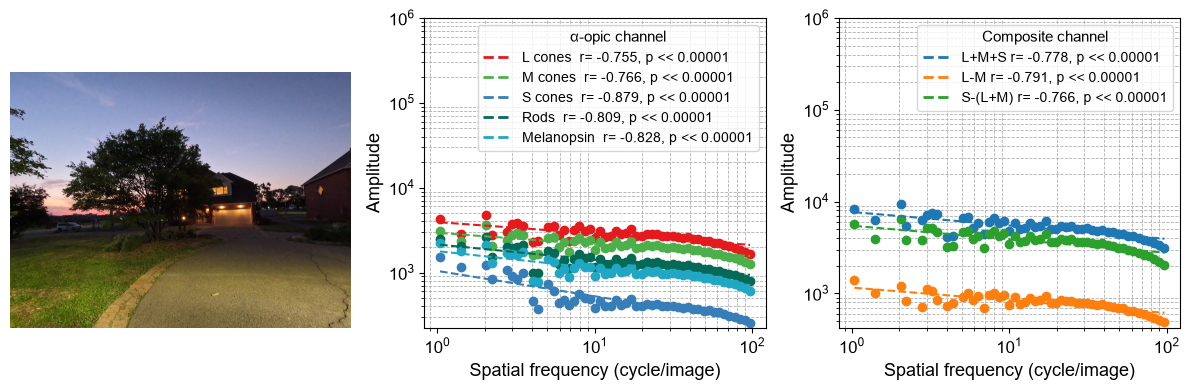

In [84]:
plot_combined_photoreceptor_composite_spectra(image_path_min_slope, file_path_min_slope )

plt.savefig(os.path.join(figures_dir, "Min_slope.png"), dpi=600, bbox_inches="tight")

## Figure 6-b (Example of a high-slope scene – image + amplitude spectrum + fit)

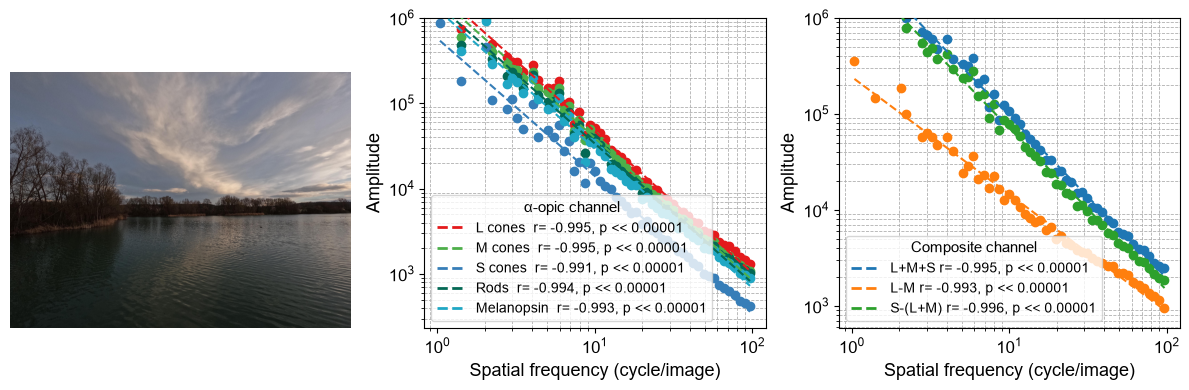

In [85]:
plot_combined_photoreceptor_composite_spectra(image_path_max_slope, file_path_max_slope )

plt.savefig(os.path.join(figures_dir, "Max_slope.png"), dpi=600, bbox_inches="tight")

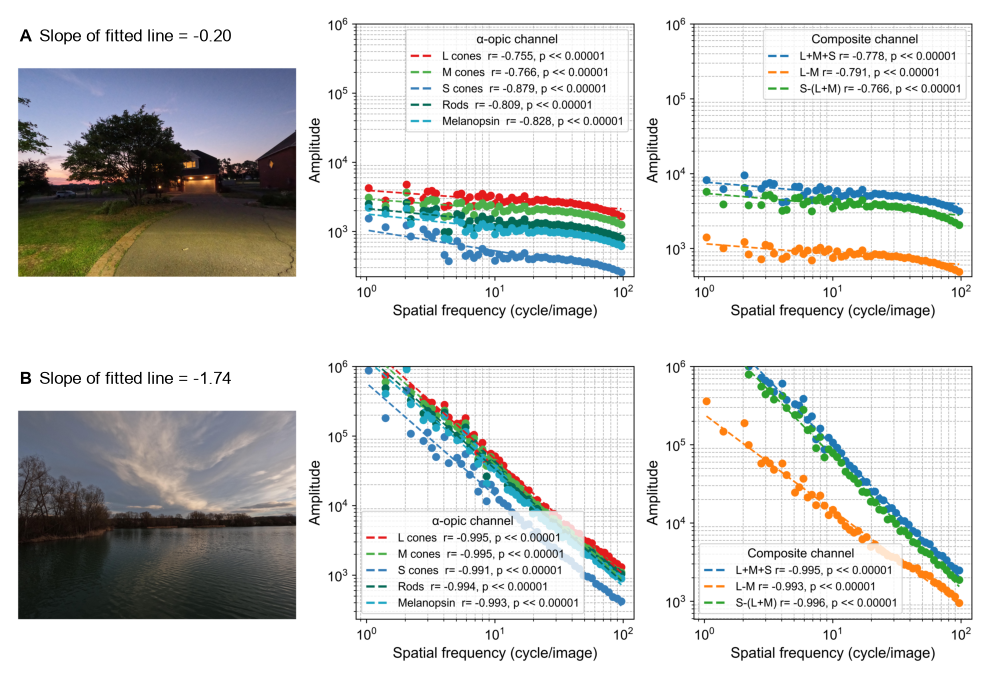

In [86]:
#Figure Six

# Create a figure with the specified size
combined_fig = plt.figure(figsize=(10, 7))

# Define the grid layout: 2 rows and 1 columns
gs = gridspec.GridSpec(2, 1)

# Load and display the third figure
ax1 = combined_fig.add_subplot(gs[0, 0])
img1 = mpimg.imread(os.path.join(figures_dir, "Min_slope.png"))
ax1.imshow(img1)
ax1.axis('off')  # Hide the axes
ax1.text(0.01,
         0.9,
         'A',
         transform=ax1.transAxes,
         fontsize=12,
         fontweight='bold',
         color='black')

ax1.text(0.025,
         0.9,
         ' Slope of fitted line = -0.20',
         transform=ax1.transAxes,
         fontsize=12,
         fontweight='normal',
         color='black')

# Load and display the fourth figure
ax2 = combined_fig.add_subplot(gs[1, 0])
img2 = mpimg.imread(os.path.join(figures_dir, "Max_slope.png"))
ax2.imshow(img2)
ax2.axis('off')  # Hide the axes
ax2.text(0.01,
         0.9,
         'B',
         transform=ax2.transAxes,
         fontsize=12,
         fontweight='bold',
         color='black')
ax2.text(0.025,
         0.9,
         ' Slope of fitted line = -1.74',
         transform=ax2.transAxes,
         fontsize=12,
         fontweight='normal',
         color='black')

plt.tight_layout()

plt.savefig(os.path.join(figures_dir, "Figure6.png"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(figures_dir, "Figure6.pdf"), dpi=600, bbox_inches="tight")

# Figure 7 (Histogram of slopes for all scenes based on view categories)

In [87]:
amplitude_spectra_regression_df = pd.read_csv(os.path.join(
    tables_dir, 'amplitude_spectra_regression_view_df.csv'),
    header=0
    )


amplitude_spectra_regression_df.rename(
    columns=lambda col: col if str(col).endswith(" view") else f"{col} view",
    inplace=True,
)

amplitude_spectra_regression_df.head()

,slope_Outdoor view,r_value_Outdoor view,p_value_Outdoor view,std_err_Outdoor view,timestamp_Outdoor view,slope_Indoor w/ window view,r_value_Indoor w/ window view,p_value_Indoor w/ window view,std_err_Indoor w/ window view,timestamp_Indoor w/ window view,slope_Indoor w/o window view,r_value_Indoor w/o window view,p_value_Indoor w/o window view,std_err_Indoor w/o window view,timestamp_Indoor w/o window view
0,-1.087343,-0.981459,4.262665e-36,0.030650,20230622T1500,-1.175796,-0.992251,3.877839e-45,0.021251,20230310T1630,-1.358264,-0.988378,6.232602e-41,0.030153,20231122T1200
1,-1.458441,-0.973162,2.781011e-32,0.049778,20230404T1400,-1.540524,-0.995436,1.221926e-50,0.021318,20231022T1500,-1.209605,-0.985573,1.083307e-38,0.029983,20231120T1230
2,-1.043394,-0.946989,2.577562e-25,0.051091,20230210T1130,-0.992490,-0.983835,1.627911e-37,0.026075,20231114T1100,-1.358286,-0.946075,3.844770e-25,0.067130,20230626T0900
3,-1.552161,-0.984029,1.221671e-37,0.040528,20230208T1030,-1.233120,-0.992735,8.298409e-46,0.021573,20230803T1400,-1.542314,-0.985124,2.248883e-38,0.038833,20230404T1130
4,-1.269518,-0.949626,7.803838e-26,0.060471,20230616T1630,-1.368656,-0.991482,3.726621e-44,0.025951,20240110T1000,-1.211955,-0.986843,1.203691e-39,0.028660,20231120T1700


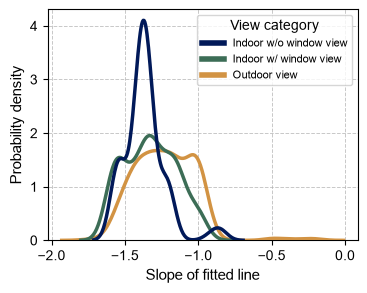

In [88]:
#Figure Seven

# Extract slope columns
slope_columns = [
    col for col in amplitude_spectra_regression_df.columns
    if col.startswith("slope_")
]

# Extract view categories from column names
view_categories = [
    col.replace("slope_", "")
    for col in slope_columns
]

# Create the plot
fig, ax = plt.subplots(figsize=(4, 3))

for slope_column, view in zip(slope_columns, view_categories):

    slopes = amplitude_spectra_regression_df[slope_column].dropna()

    sns.kdeplot(
        slopes,
        ax=ax,
        label=f"{view}",
        color=view_color_mapping[view],
        linewidth=2.5,
        zorder=3
    )

ax.set_xlabel("Slope of fitted line", fontsize=11)
ax.set_ylabel("Probability density", fontsize=11)

# Legend using current view categories
handles = [
    plt.Line2D(
        [0], [0],
        color=view_color_mapping[view],
        lw=4,
        label=f"{view}"
    )
    for view in ['Indoor w/o window view', 'Indoor w/ window view', 'Outdoor view']
]

ax.legend(
    handles=handles,
    title="View category",
    loc="upper right",
    fontsize=8,
    title_fontsize=10,
    frameon=True
)

ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)
ax.set_axisbelow(True)

plt.savefig(os.path.join(figures_dir, "Figure7.png"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(figures_dir, "Figure7.pdf"), dpi=600, bbox_inches="tight")

## Supplementary

C:\Users\ntabandeh\AppData\Local\Temp\ipykernel_10204\1439759135.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_wp_jeti_metadata_df['timestamp_dt'] = pd.to_datetime(


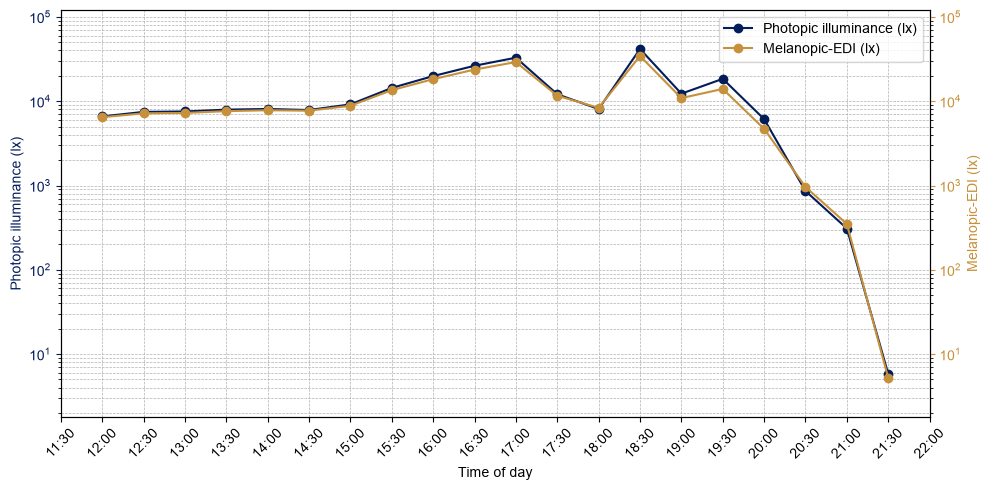

In [89]:
# Plot photopic illuminance and melanopic EDI timelapse for date 2023-06-22

# convert timestamp column to datetime
merged_wp_jeti_metadata_df['timestamp_dt'] = pd.to_datetime(
    merged_wp_jeti_metadata_df['timestamp'],
    format='%Y%m%dT%H%M'
)
# filter for the target date
target_date = pd.Timestamp('2023-06-22')

df_day = merged_wp_jeti_metadata_df.loc[
    merged_wp_jeti_metadata_df['timestamp_dt'].dt.date == target_date.date()
].copy()


# ensure sorted by time (important for plotting)
df_day = df_day.sort_values('timestamp_dt')

# --- columns ---
col_left = 'Illuminance [lx] (CIE1931 2°)'
col_right = 'X v,mel,D65 (MEDI) [lx]'

# ---------------------------
# COLORS FROM BATLOW
# ---------------------------
cmap = cm.batlow
color_left = cmap(0.01)
color_right = cmap(0.64)

fig, ax = plt.subplots(figsize=(10, 5))

# plot left
l1, = ax.plot(
    df_day['timestamp_dt'],
    df_day[col_left],
    marker='o',
    linestyle='-',
    color=color_left,
    label='Photopic illuminance (lx)'
)

ax.set_xlabel('Time of day')
ax.set_ylabel('Photopic illuminance (lx)', color=color_left)
ax.tick_params(axis='y', colors=color_left)

# LOG SCALE (LEFT)
ax.set_yscale('log')

# second axis (RIGHT)
ax2 = ax.twinx()

# plot right
l2, = ax2.plot(
    df_day['timestamp_dt'],
    df_day[col_right],
    marker='o',
    linestyle='-',
    color=color_right,
    label='Melanopic-EDI (lx)'
)

ax2.set_ylabel('Melanopic-EDI (lx)', color=color_right)
ax2.tick_params(axis='y', colors=color_right)

# LOG SCALE (RIGHT)
ax2.set_yscale('log')

# ---------------------------
# LOG-SAFE Y LIMITS + PADDING (WORKS FOR LOG)
# ---------------------------
# Use BOTH series to set a common limit range, and ignore non-positive values
vals = np.concatenate([
    df_day[col_left].to_numpy(dtype=float),
    df_day[col_right].to_numpy(dtype=float)
])
vals = vals[np.isfinite(vals) & (vals > 0)]

ymin_data = vals.min()
ymax_data = vals.max()

pad_factor = 2.9  # 30% padding (multiplicative)

ymin = ymin_data / pad_factor
ymax = ymax_data * pad_factor

ax.set_ylim(ymin, ymax)

# synchronize right axis exactly
ax2.set_autoscaley_on(False)
ax2.set_ylim(ymin, ymax)

# identical ticks and labels (use left ticks)
ticks = ax.get_yticks()
ax2.yaxis.set_major_locator(mticker.FixedLocator(ticks))
ax2.yaxis.set_major_formatter(ax.yaxis.get_major_formatter())

# legend
ax.legend([l1, l2], [l1.get_label(), l2.get_label()], loc='upper right')
#ax.get_legend().set_title(target_date.strftime('%Y-%m-%d'))

# x axis formatting
ax.xaxis.set_major_locator(mdates.MinuteLocator(byminute=[0, 30]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

ax.set_xlim(
    df_day['timestamp_dt'].min() - pd.Timedelta(minutes=30),
    df_day['timestamp_dt'].max() + pd.Timedelta(minutes=30)
)

# rotate labels for readability
plt.setp(ax.get_xticklabels(), rotation=45)

ax.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()

In [90]:
melanopsin_list = list(zip(
    df_day['timestamp_dt'],
    df_day['average_radiances_Melanopsin']
))

print(melanopsin_list)

[(Timestamp('2023-06-22 12:00:00'), 2.2574), (Timestamp('2023-06-22 12:30:00'), 2.1512), (Timestamp('2023-06-22 13:00:00'), 2.0713), (Timestamp('2023-06-22 13:30:00'), 1.9136), (Timestamp('2023-06-22 14:00:00'), 1.7582), (Timestamp('2023-06-22 14:30:00'), 1.5634), (Timestamp('2023-06-22 15:00:00'), 1.403), (Timestamp('2023-06-22 15:30:00'), 1.293), (Timestamp('2023-06-22 16:00:00'), 1.1689), (Timestamp('2023-06-22 16:30:00'), 1.1168), (Timestamp('2023-06-22 17:00:00'), 1.1029), (Timestamp('2023-06-22 17:30:00'), 1.0841), (Timestamp('2023-06-22 18:00:00'), 1.0359), (Timestamp('2023-06-22 18:30:00'), 1.0206), (Timestamp('2023-06-22 19:00:00'), 0.8726), (Timestamp('2023-06-22 19:30:00'), 0.7604), (Timestamp('2023-06-22 20:00:00'), 0.4282), (Timestamp('2023-06-22 20:30:00'), 0.1349), (Timestamp('2023-06-22 21:00:00'), 0.0493), (Timestamp('2023-06-22 21:30:00'), 0.0013)]


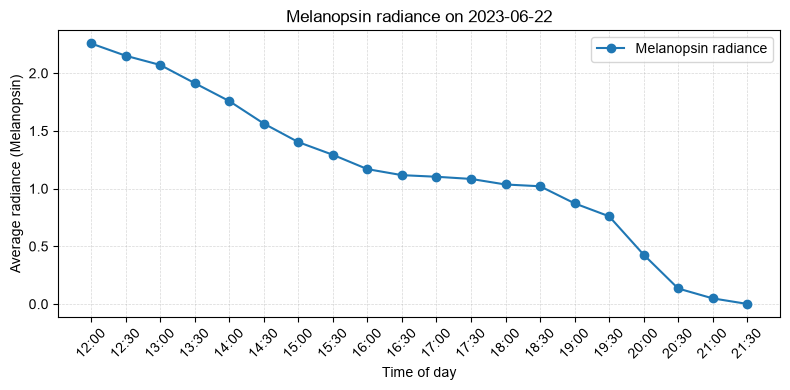

In [91]:
# Average melanopic radiance timelapse a cross the day

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    df_day['timestamp_dt'],
    df_day['average_radiances_Melanopsin'],
    linestyle='-',
    marker='o',
    label='Melanopsin radiance'
)

ax.set_xlabel('Time of day')
ax.set_ylabel('Average radiance (Melanopsin)')
ax.set_title('Melanopsin radiance on 2023-06-22')

ax.legend(loc='best')

ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

# format x axis
ax.xaxis.set_major_locator(mdates.MinuteLocator(byminute=[0, 30]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.setp(ax.get_xticklabels(), rotation=45)

plt.tight_layout()

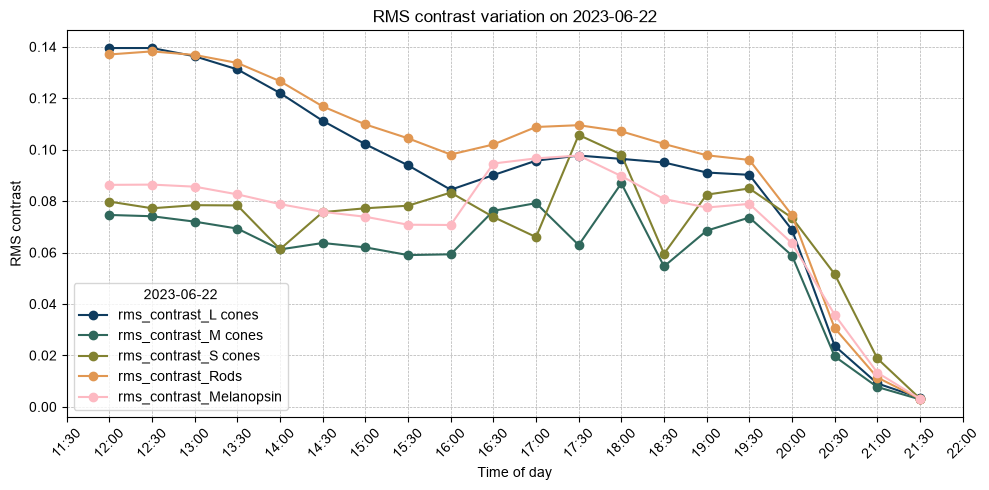

In [92]:
# RMS contrast variation for date 2023-06-22

# columns to plot
rms_cols = [
    'rms_contrast_L cones',
    'rms_contrast_M cones',
    'rms_contrast_S cones',
    'rms_contrast_Rods',
    'rms_contrast_Melanopsin'
]
colors = [cmap(x) for x in [0.10, 0.30, 0.50, 0.70, 0.90]]

# create figure and axis
fig, ax = plt.subplots(figsize=(10, 5))

# plot each RMS line
for col, color in zip(rms_cols, colors):
    ax.plot(
        df_day['timestamp_dt'],
        df_day[col],
        marker='o',
        linestyle='-',
        color=color,
        label=col
    )

# labels and title
ax.set_xlabel('Time of day')
ax.set_ylabel('RMS contrast')
ax.set_title(f'RMS contrast variation on {target_date:%Y-%m-%d}')

# x axis formatting (same as before)
ax.xaxis.set_major_locator(mdates.MinuteLocator(byminute=[0, 30]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# add 30 minutes padding on both sides
ax.set_xlim(
    df_day['timestamp_dt'].min() - pd.Timedelta(minutes=30),
    df_day['timestamp_dt'].max() + pd.Timedelta(minutes=30)
)

# rotate labels for readability
plt.setp(ax.get_xticklabels(), rotation=45)

# grid + legend
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.legend(title=target_date.strftime('%Y-%m-%d'), loc='best')

plt.tight_layout()

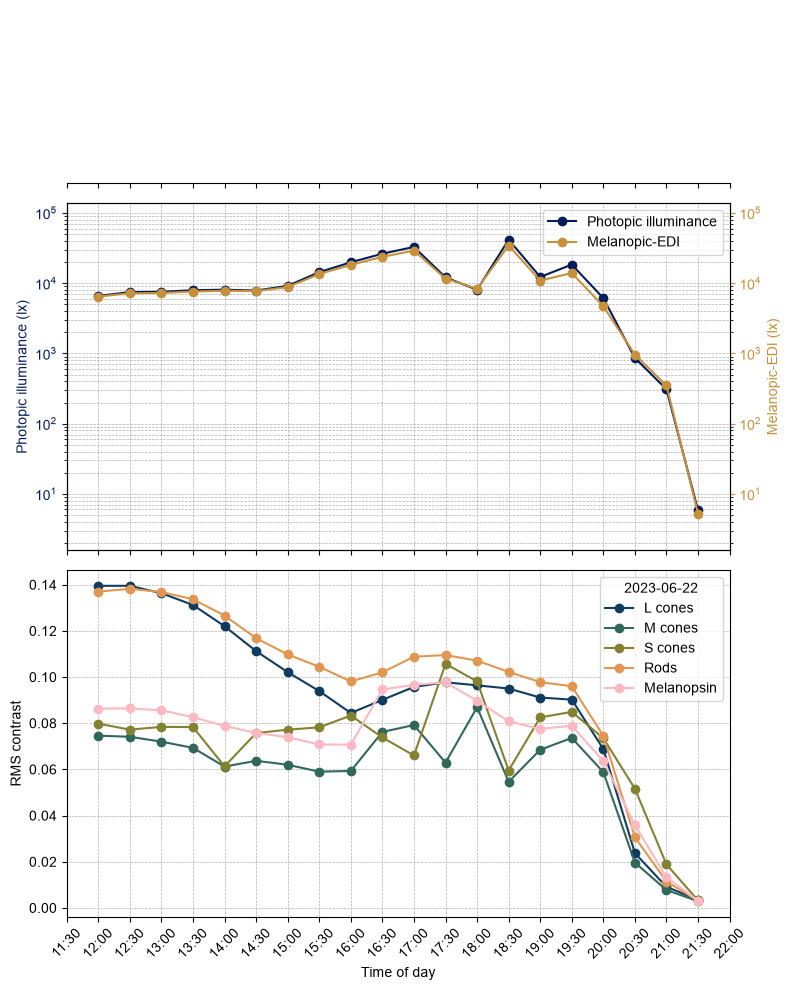

In [93]:
# Sup figure

# convert timestamp column to datetime
merged_wp_jeti_metadata_df['timestamp_dt'] = pd.to_datetime(
    merged_wp_jeti_metadata_df['timestamp'],
    format='%Y%m%dT%H%M'
)

# filter for the target date
target_date = pd.Timestamp('2023-06-22')
df_day = merged_wp_jeti_metadata_df.loc[
    merged_wp_jeti_metadata_df['timestamp_dt'].dt.date == target_date.date()
].copy()

df_day = df_day.sort_values('timestamp_dt')

# columns
col_left = 'Illuminance [lx] (CIE1931 2°)'
col_right = 'X v,mel,D65 (MEDI) [lx]'

rms_cols = [
    'rms_contrast_L cones',
    'rms_contrast_M cones',
    'rms_contrast_S cones',
    'rms_contrast_Rods',
    'rms_contrast_Melanopsin'
]

# batlow colors
cmap = cm.batlow
color_left = cmap(0.01)
color_right = cmap(0.64)
rms_colors = [cmap(x) for x in [0.10, 0.30, 0.50, 0.70, 0.90]]

# ---------------------------
# FIGURE WITH TWO SUBPLOTS
# ---------------------------
fig, (ax0, ax1, ax2) = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(8, 10),
    sharex=True,
    gridspec_kw={'height_ratios': [1, 2, 2]}
)

# keep shared x-axis, hide only y-axis visuals
ax0.get_yaxis().set_visible(False)
ax0.spines['left'].set_visible(False)
ax0.spines['right'].set_visible(False)
ax0.spines['top'].set_visible(False)

# ===========================
# TOP: Illuminance + Melanopic (LOG)
# ===========================

l1, = ax1.plot(
    df_day['timestamp_dt'],
    df_day[col_left],
    marker='o',
    linestyle='-',
    color=color_left,
    label='Photopic illuminance'
)

ax1.set_ylabel('Photopic illuminance (lx)', color=color_left)
ax1.tick_params(axis='y', colors=color_left)
ax1.set_yscale('log')

ax1b = ax1.twinx()

l2, = ax1b.plot(
    df_day['timestamp_dt'],
    df_day[col_right],
    marker='o',
    linestyle='-',
    color=color_right,
    label='Melanopic-EDI'
)

ax1b.set_ylabel('Melanopic-EDI (lx)', color=color_right)
ax1b.tick_params(axis='y', colors=color_right)
ax1b.set_yscale('log')

# ---------------------------
# LOG-SAFE synchronized limits + padding (use BOTH series; ignore <=0)
# ---------------------------
vals = np.concatenate([
    df_day[col_left].to_numpy(dtype=float),
    df_day[col_right].to_numpy(dtype=float)
])
vals = vals[np.isfinite(vals) & (vals > 0)]

ymin_data = vals.min()
ymax_data = vals.max()

pad_factor = 3.3  # 30% multiplicative padding

ymin = ymin_data / pad_factor
ymax = ymax_data * pad_factor

ax1.set_ylim(ymin, ymax)
ax1b.set_autoscaley_on(False)
ax1b.set_ylim(ymin, ymax)

# identical ticks and labels (use left ticks)
ticks = ax1.get_yticks()
ax1b.yaxis.set_major_locator(mticker.FixedLocator(ticks))
ax1b.yaxis.set_major_formatter(ax1.yaxis.get_major_formatter())

ax1.legend(
    [l1, l2],
    [l1.get_label(), l2.get_label()],
    #title=target_date.strftime('%Y-%m-%d'),
    loc='upper right'
)

ax1.grid(True, which='both', linestyle='--', linewidth=0.5)

# ===========================
# BOTTOM: RMS contrast
# ===========================

for col, color in zip(rms_cols, rms_colors):
    ax2.plot(
        df_day['timestamp_dt'],
        df_day[col],
        marker='o',
        linestyle='-',
        color=color,
        label=col.replace('rms_contrast_', '')
    )

ax2.set_ylabel('RMS contrast')
ax2.set_xlabel('Time of day')

ax2.legend(
    title=target_date.strftime('%Y-%m-%d'),
    loc='upper right'
)

ax2.grid(True, linestyle='--', linewidth=0.5, zorder=0)

# ===========================
# Shared X formatting
# ===========================

ax2.xaxis.set_major_locator(mdates.MinuteLocator(byminute=[0, 30]))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

ax2.set_xlim(
    df_day['timestamp_dt'].min() - pd.Timedelta(minutes=30),
    df_day['timestamp_dt'].max() + pd.Timedelta(minutes=30)
)

plt.setp(ax2.get_xticklabels(), rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "Figure_Sup.png"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(figures_dir, "Figure_sup.pdf"), dpi=600, bbox_inches="tight")